<h1>RISING COST OF LIVING IN CAMEROON</h1>

In [1]:
#cleaning data
import warnings, re
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
#load data
df_raw = pd.read_excel(
    'Rising Cost of Living in Cameroon (Responses).xlsx',
    sheet_name='Form Responses 1'
)
print('Raw shape:', df_raw.shape)
df_raw.head(10)


Raw shape: (1810, 33)


,Employment_Status,Highest_Education_Level,Age_Group,Current_City_Residence,Monthly_Household_Income_Range(XAF),Household_Size_Supported,Bulk_Food_Purchase_Frequency,Percentage_Income_To_Food,Reduced_Food_Quality/Quantity,Monthly_Food_Spend_XAF,...,Skipped_Medical_Treatment_Cost,Schooling_Cost_Increased_Scale,Has_Health_Insurance,Average_Monthly_Healthcare_Spend_XAF,School_Fees_Per_Child_XAF,Highest_Burden_Expenditure_Category,Expect_Cost_Of_Living_Increase_5Yrs,Taken_Measures_To_Cope,Primary_Contributor_To_Cost_Of_Living,Year_Noticeable_Impact
0,Self-employed,Postgraduate,18 - 25,Bamenda,"200,001 - 500,000",Me alone,Always,20 - 40%,No,30000,...,"Yes, once",1,No,30000,1000000,Education,Definitely yes,Taking a second job,Inflation (rising prices),2023
1,Student,Undergraduate,18 - 25,Buea,"Below 50,000",1,Rarely,41 - 60%,"Yes, only quantity",45000,...,"Yes, more than once",3,No,25000,150000,Food,Definitely yes,Reduced spending,Inflation (rising prices),2023
2,Student,Undergraduate,18 - 25,Buea,"Below 50,000",2,Always,more than 60%,"Yes, only quantity",30000,...,"Yes, more than once",1,No,10000,It varies,Food,Definitely yes,Reduced spending,Inflation (rising prices),2018
3,Student,Undergraduate,18 - 25,Buea,"200,001 - 500,000",3,Always,41 - 60%,"Yes, only quantity",100000-300000,...,No,2,Yes,We have insurance we don’t spend a dime,Depends on the school level,Food,Definitely yes,Started a small business,Inflation (rising prices),2021
4,Student,Undergraduate,18 - 25,Buea,"Below 50,000",6,Always,20 - 40%,"Yes, both quantity and quality",100000,...,"Yes, more than once",1,No,100000,120000,Transportation,Definitely yes,Reduced spending,Government policies,2022
5,Student,Vocational,18 - 25,Tiko,"Below 50,000",7,Sometimes,20 - 40%,"Yes, only quantity","About 200,000",...,"Yes, once",2,No,Don’t know,Very much,Food,Probably yes,Reduced spending,Inflation (rising prices),2019
6,Student,Vocational,18 - 25,Tiko,"Below 50,000",7,Sometimes,20 - 40%,"Yes, only quantity","About 200,000",...,"Yes, once",2,No,Don’t know,Very much,Food,Probably yes,Reduced spending,Inflation (rising prices),2019
7,Student,Postgraduate,18 - 25,Buea,"50,000 - 100,000",2,Sometimes,Less than 20%,"Yes, both quantity and quality",35000fcfrs,...,"Yes, once",2,No,5000,2035000,Utilities,Probably yes,Reduced spending,Inflation (rising prices),2020
8,Student,Undergraduate,18 - 25,Buea,"Below 50,000",5,Rarely,more than 60%,"Yes, both quantity and quality",50 000,...,"Yes, once",3,No,25000,360000,Rent,Definitely yes,Borrowed money,Inflation (rising prices),2025
9,Student,Undergraduate,18 - 25,Buea,"50,000 - 100,000",2,Sometimes,20 - 40%,"Yes, only quantity",65000,...,No,3,No,10000,299000,Education,Definitely yes,"Taking a second job, Started a small business",Inflation (rising prices),2024


In [3]:
#Renaming columns
df_raw.columns = [
    'Employment_Status','Education_Level','Age_Group',
    'City','Income_Range','Household_Size','Bulk_Food_Freq',
    'Pct_Income_Food','Reduced_Food','Food_Spend_Raw','Food_Spend_Cat',
    'Top_Food_Item','Transport_Spend_Cat','Fuel_Impact','Transport_Mode',
    'Transport_Trips','Fare_Increase','Times_Moved','Power_Cuts',
    'Pct_Income_Rent','Rent_XAF','Utilities_XAF','Rent_Increased',
    'Skipped_Medical','School_Cost_Scale','Has_Insurance',
    'Healthcare_Spend','School_Fees','Burden_Category',
    'Expect_Increase','Coping_Measures','Cost_Driver','Year_Impact'
]

In [4]:
#Convert numeric columns that may have been stored as object
def to_numeric_safe(col):
    return pd.to_numeric(col, errors='coerce')

for c in ['Rent_XAF','Utilities_XAF','Healthcare_Spend','School_Fees','Food_Spend_Raw','Household_Size']:
    df_raw[c] = to_numeric_safe(df_raw[c])


In [5]:
#Ordinal income map
income_map = {
    'Below 50,000': 25000,
    '50,000 - 100,000': 75000,
    '100,001 - 200,000': 150000,
    '100,001-200,000': 150000,
    '200,001 - 500,000': 350000,
    '200,001-500,000': 350000,
    'Above 500,000': 600000,
}
df_raw['Income_Numeric'] = df_raw['Income_Range'].map(income_map).fillna(150000)


In [6]:
#Ordinal food % map
food_pct_map = {
    'Less than 20%': 10, '20 - 40%': 30, '20-40%': 30,
    '41 - 60%': 50, '41-60%': 50,
    'more than 60%': 70, 'More than 60%': 70,
}
df_raw['Food_Pct_Num'] = df_raw['Pct_Income_Food'].map(food_pct_map).fillna(40)


In [7]:
#Ordinal rent % map
rent_pct_map = {
    'Less than 20%': 10, '20 - 35%': 27, '20-35%': 27,
    '36 - 50%': 43, '36-50%': 43,
    'More than 50%': 60,
}
df_raw['Rent_Pct_Num'] = df_raw['Pct_Income_Rent'].map(rent_pct_map).fillna(30)


In [8]:
#Fill median for numeric NAs
for c in ['Rent_XAF','Utilities_XAF','Healthcare_Spend','School_Fees',
          'Food_Spend_Raw','Household_Size','Fuel_Impact',
          'Transport_Trips','School_Cost_Scale']:
    df_raw[c] = df_raw[c].fillna(df_raw[c].median())

print('Cleaned shape:', df_raw.shape)
df_raw[['City','Income_Range','Income_Numeric','Food_Pct_Num','Rent_XAF']].head()

Cleaned shape: (1810, 36)


,City,Income_Range,Income_Numeric,Food_Pct_Num,Rent_XAF
0,Bamenda,"200,001 - 500,000",350000.0,30,2500000.0
1,Buea,"Below 50,000",25000.0,50,35000.0
2,Buea,"Below 50,000",25000.0,70,30000.0
3,Buea,"200,001 - 500,000",350000.0,50,33000.0
4,Buea,"Below 50,000",25000.0,30,60000.0


In [9]:
#Encode all categorical columns to integer codes
cat_cols = ['Employment_Status','Education_Level','Age_Group','City',
            'Income_Range','Bulk_Food_Freq','Reduced_Food','Food_Spend_Cat',
            'Top_Food_Item','Transport_Spend_Cat','Transport_Mode',
            'Fare_Increase','Times_Moved','Power_Cuts','Pct_Income_Rent',
            'Rent_Increased','Skipped_Medical','Has_Insurance',
            'Burden_Category','Expect_Increase','Cost_Driver']

le_dict = {}
df = df_raw.copy()
for c in cat_cols:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c].astype(str))
    le_dict[c] = le

print('Encoding complete. Shape:', df.shape)

Encoding complete. Shape: (1810, 57)


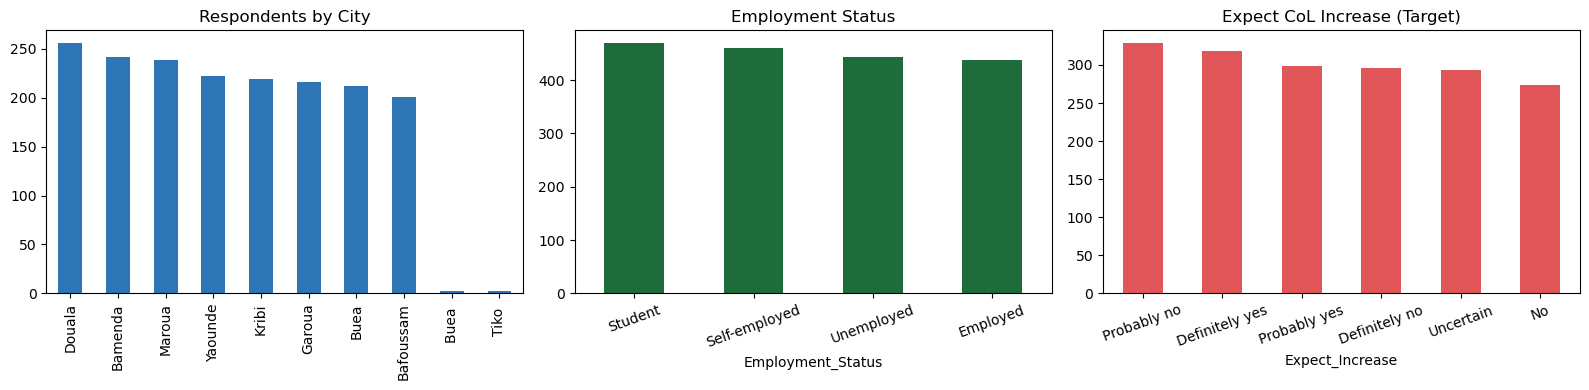

In [10]:
# ── Quick Exploratory Data Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df_raw['City'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='#2E75B6')
axes[0].set_title('Respondents by City'); axes[0].set_xlabel('')
df_raw['Employment_Status'].value_counts().plot(kind='bar', ax=axes[1], color='#1E6B3C', rot=20)
axes[1].set_title('Employment Status')
df_raw['Expect_Increase'].value_counts().plot(kind='bar', ax=axes[2], color='#E15759', rot=20)
axes[2].set_title('Expect CoL Increase (Target)')
plt.tight_layout(); plt.savefig('col_eda_overview.png', dpi=120); 
plt.show()


<h1>Step 1:Classification: Decision Tree & k-NN</h1>

In [11]:
#Step1:Simplify target to 3 classes
def simplify_expect(v):
    v = str(v).strip().lower()
    if v in ['definitely yes', 'probably yes']: return 'Yes'
    if v in ['definitely no', 'probably no', 'no']: return 'No'
    return 'Uncertain'

df['Target_Expect'] = df_raw['Expect_Increase'].apply(simplify_expect)
print(df['Target_Expect'].value_counts())

Target_Expect
No           899
Yes          617
Uncertain    294
Name: count, dtype: int64


In [12]:
#Step2:Feature selection
feat_cols_lab1 = [
    'Employment_Status_enc','Education_Level_enc','Age_Group_enc',
    'City_enc','Household_Size','Fuel_Impact','Transport_Trips',
    'School_Cost_Scale','Income_Numeric','Food_Pct_Num',
    'Rent_Pct_Num','Rent_XAF','Utilities_XAF','Healthcare_Spend'
]

X1 = df[feat_cols_lab1].fillna(0)
y1_raw = df['Target_Expect']
le1 = LabelEncoder()
y1 = le1.fit_transform(y1_raw)   # No=0, Uncertain=1, Yes=2

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1)
print(f'Train: {X1_train.shape}  Test: {X1_test.shape}')
print('Classes:', le1.classes_)

Train: (1267, 14)  Test: (543, 14)
Classes: ['No' 'Uncertain' 'Yes']


<h2>Decision Tree</h2>

In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [14]:
dt1 = DecisionTreeClassifier(max_depth=4, random_state=42)
dt1.fit(X1_train, y1_train)
y1_pred_dt = dt1.predict(X1_test)

In [15]:
print('=== Decision Tree (max_depth=4) ===')
print(classification_report(y1_test, y1_pred_dt, target_names=le1.classes_))

=== Decision Tree (max_depth=4) ===
              precision    recall  f1-score   support

          No       0.50      0.99      0.67       270
   Uncertain       0.00      0.00      0.00        88
         Yes       0.50      0.03      0.05       185

    accuracy                           0.50       543
   macro avg       0.33      0.34      0.24       543
weighted avg       0.42      0.50      0.35       543



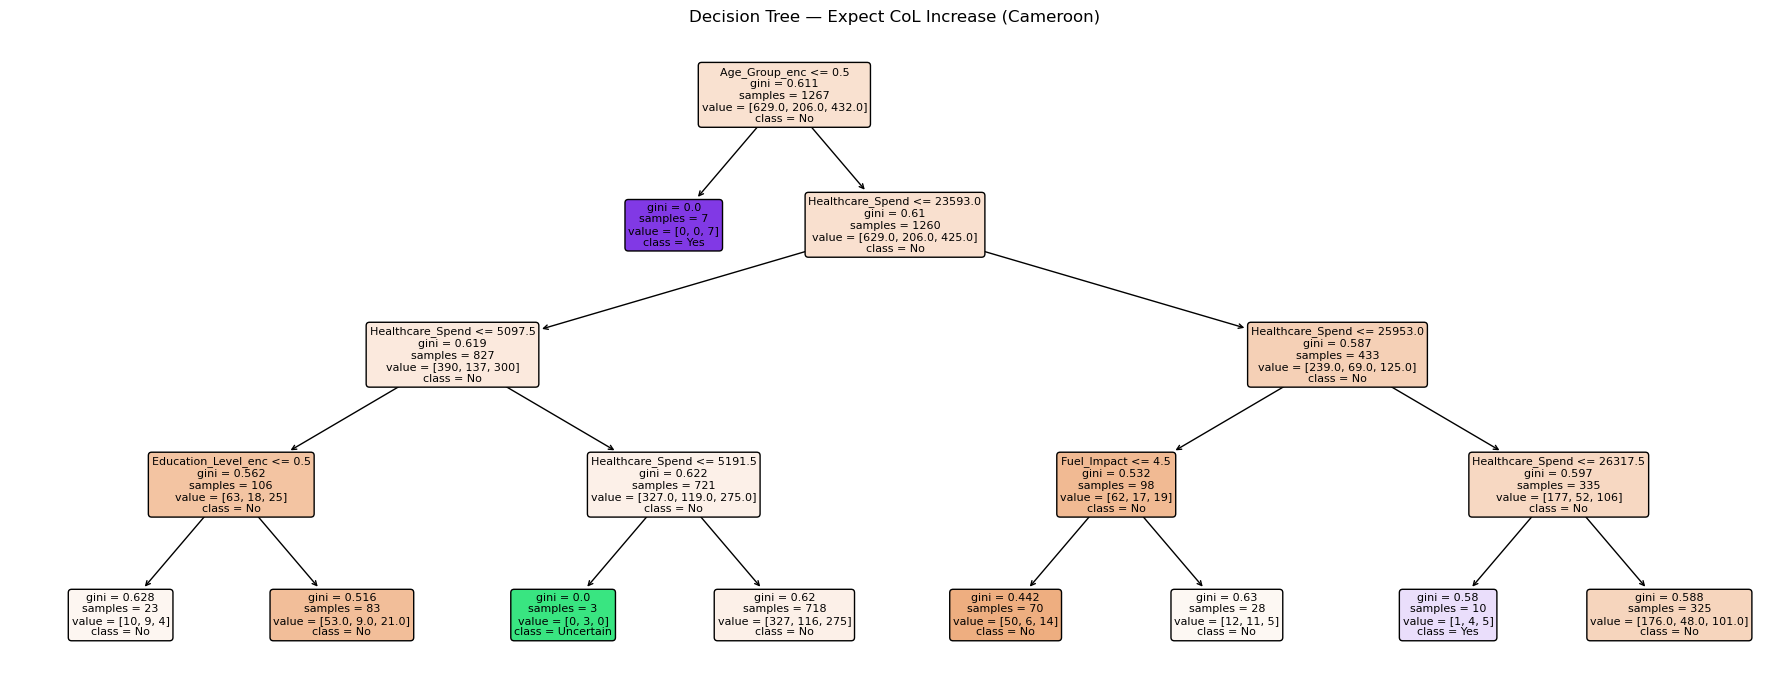

In [16]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt1, feature_names=feat_cols_lab1, class_names=le1.classes_,
          filled=True, rounded=True, ax=ax, fontsize=8)
plt.title('Decision Tree — Expect CoL Increase (Cameroon)')
plt.tight_layout(); plt.savefig('lab1_decision_tree.png', dpi=120); plt.show()


<h2>K-Nearest 
Neighbors Classifier</h2>


In [17]:
from sklearn.neighbors import KNeighborsClassifier

In [18]:
sc1 = StandardScaler()
X1_train_s = sc1.fit_transform(X1_train)
X1_test_s  = sc1.transform(X1_test)

In [19]:
k_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X1_train_s, y1_train)
    k_scores.append(knn.score(X1_test_s, y1_test))

best_k = k_scores.index(max(k_scores)) + 1
print(f'Best k: {best_k}  (Accuracy: {max(k_scores):.4f})')

Best k: 20  (Accuracy: 0.4641)


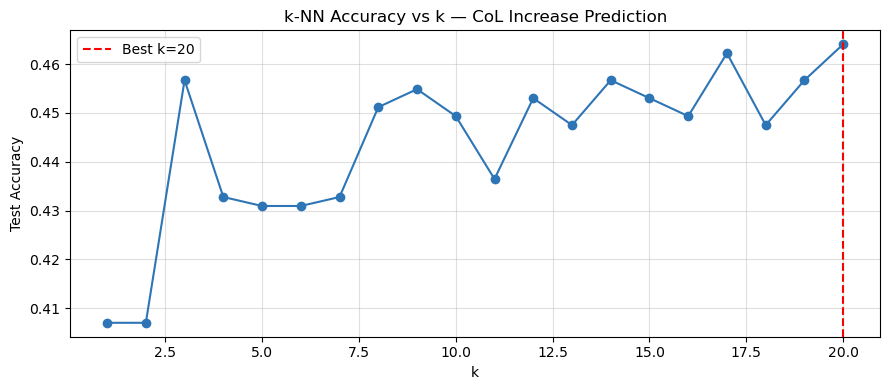

In [20]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, 21), k_scores, marker='o', color='#2E75B6')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k'); plt.ylabel('Test Accuracy')
plt.title('k-NN Accuracy vs k — CoL Increase Prediction'); plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('lab1_knn_tuning.png', dpi=120); 
plt.show()

In [21]:
knn1 = KNeighborsClassifier(n_neighbors=best_k)
knn1.fit(X1_train_s, y1_train)
y1_pred_knn = knn1.predict(X1_test_s)
print('\n=== k-NN ===')
print(classification_report(y1_test, y1_pred_knn, target_names=le1.classes_))


=== k-NN ===
              precision    recall  f1-score   support

          No       0.49      0.82      0.62       270
   Uncertain       0.00      0.00      0.00        88
         Yes       0.34      0.16      0.22       185

    accuracy                           0.46       543
   macro avg       0.28      0.33      0.28       543
weighted avg       0.36      0.46      0.38       543



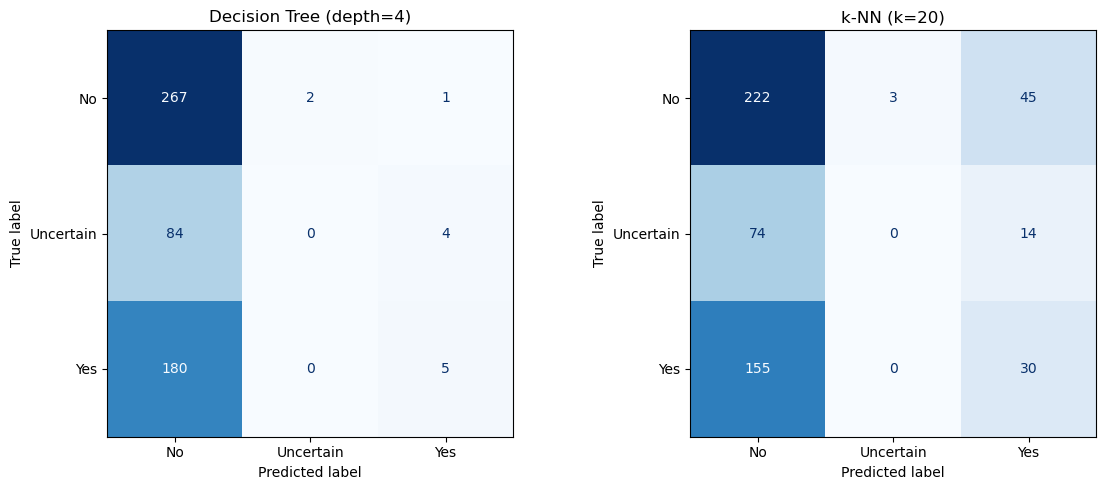

In [22]:
#Step5: Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in zip(axes,
        [y1_pred_dt, y1_pred_knn],
        [f'Decision Tree (depth=4)', f'k-NN (k={best_k})']):
    cm = confusion_matrix(y1_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=le1.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.tight_layout(); plt.savefig('lab1_confusion.png', dpi=120); 
plt.show()

In [23]:
#Depth vs accuracy trade-off
train_acc, test_acc, depths = [], [], [1,2,3,4,5,None]
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X1_train, y1_train)
    train_acc.append(m.score(X1_train, y1_train))
    test_acc.append(m.score(X1_test, y1_test))

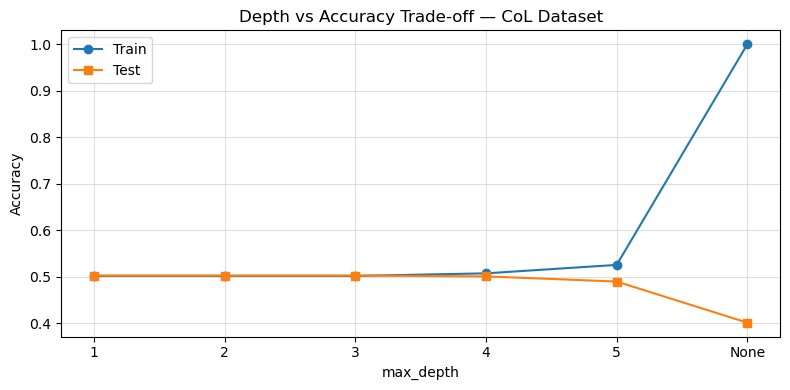

depth=1     train=0.5020  test=0.5028  gap=-0.0008
depth=2     train=0.5020  test=0.5028  gap=-0.0008
depth=3     train=0.5020  test=0.5028  gap=-0.0008
depth=4     train=0.5075  test=0.5009  gap=0.0066
depth=5     train=0.5257  test=0.4899  gap=0.0358
depth=None  train=1.0000  test=0.4015  gap=0.5985


In [24]:
plt.figure(figsize=(8, 4))
plt.plot([str(d) for d in depths], train_acc, marker='o', label='Train')
plt.plot([str(d) for d in depths], test_acc,  marker='s', label='Test')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Depth vs Accuracy Trade-off — CoL Dataset')
plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('lab1_depth_accuracy.png', dpi=120); plt.show()
for d, tr, te in zip(depths, train_acc, test_acc):
    print(f'depth={str(d):4s}  train={tr:.4f}  test={te:.4f}  gap={tr-te:.4f}')

<h1>Step 2:Clustering: k-Means & DBSCANN</h1>

In [25]:
#Step 1: Build feature matrix
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

feat_lab2 = ['Income_Numeric','Food_Pct_Num','Rent_Pct_Num',
             'Household_Size','Fuel_Impact','Transport_Trips',
             'Utilities_XAF','Healthcare_Spend','School_Cost_Scale']

X2 = df[feat_lab2].fillna(0)
sc2 = StandardScaler()
X2_s = sc2.fit_transform(X2)
print('Clustering matrix shape:', X2_s.shape)

Clustering matrix shape: (1810, 9)


In [26]:
pip install --upgrade threadpoolctl

In [27]:
#Step2: Elbow method
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X2_s)
    inertias.append(km.inertia_)

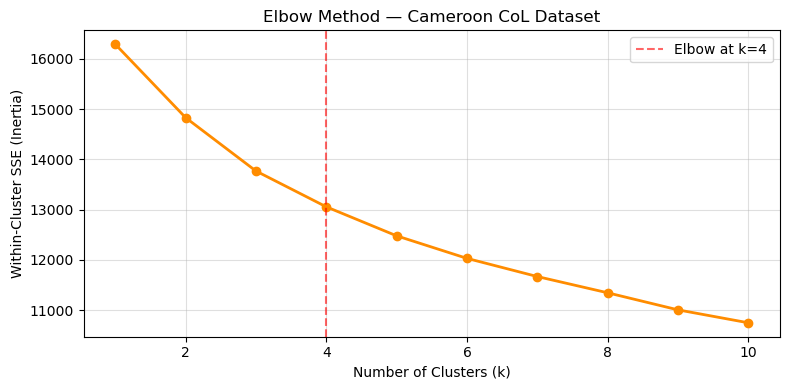

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, marker='o', color='darkorange', linewidth=2)
plt.axvline(4, color='red', linestyle='--', alpha=0.6, label='Elbow at k=4')
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Within-Cluster SSE (Inertia)')
plt.title('Elbow Method — Cameroon CoL Dataset')
plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout(); plt.savefig('lab2_elbow.png', dpi=120); 
plt.show()

In [29]:
km2 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km2 = km2.fit_predict(X2_s)

In [30]:
sil2 = silhouette_score(X2_s, labels_km2)
print(f'Silhouette Score (k=4): {sil2:.4f}')

Silhouette Score (k=4): 0.0846


In [31]:
pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(X2_s)
print(f'PCA variance explained: {pca2.explained_variance_ratio_.sum():.3f}')

PCA variance explained: 0.243


In [32]:
cluster_names = {0:'Low-Burden', 1:'Mid-Burden', 2:'High-Burden', 3:'Very-High-Burden'}
colors_map = {0:'#2E75B6', 1:'#F0A500', 2:'#E15759', 3:'#8B0000'}

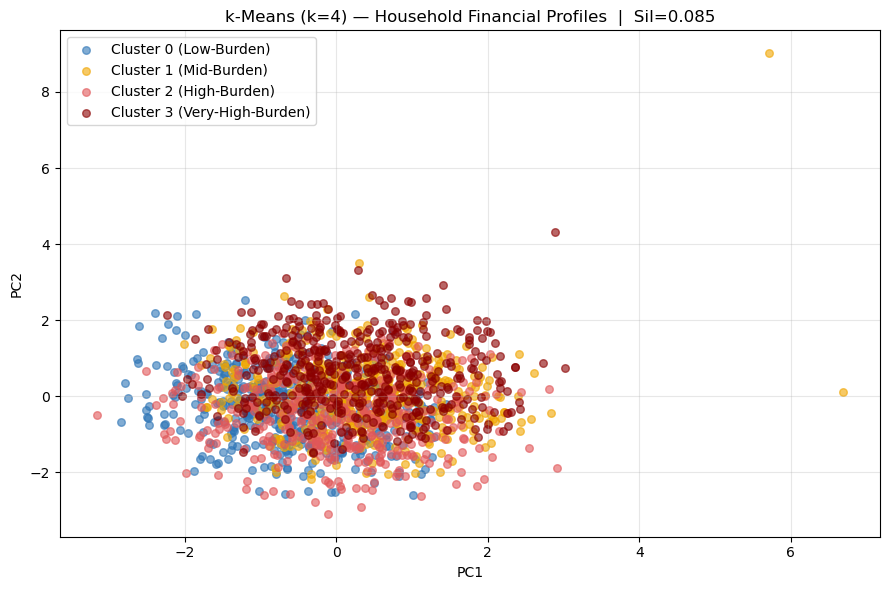

In [33]:
plt.figure(figsize=(9, 6))
for c in range(4):
    mask = labels_km2 == c
    plt.scatter(X2_pca[mask, 0], X2_pca[mask, 1],
                label=f'Cluster {c} ({cluster_names[c]})',
                alpha=0.6, s=30, color=colors_map[c])
plt.title(f'k-Means (k=4) — Household Financial Profiles  |  Sil={sil2:.3f}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('lab2_kmeans_pca.png', dpi=120); 
plt.show()

In [34]:
# Cluster profile table
df['Cluster'] = labels_km2
print('\nCluster profiles (means):')
print(df.groupby('Cluster')[feat_lab2].mean().round(0).to_string())


Cluster profiles (means):
         Income_Numeric  Food_Pct_Num  Rent_Pct_Num  Household_Size  Fuel_Impact  Transport_Trips  Utilities_XAF  Healthcare_Spend  School_Cost_Scale
Cluster                                                                                                                                              
0              164033.0          41.0          36.0             5.0          4.0              7.0        13473.0           18113.0                5.0
1              169025.0          40.0          52.0             5.0          4.0              7.0        14118.0           19274.0                3.0
2              586641.0          40.0          36.0             4.0          4.0              7.0        12912.0           18990.0                4.0
3              161874.0          40.0          18.0             4.0          4.0              7.0        14428.0           18172.0                3.0


In [35]:
#Step4: DBSCAN
db2 = DBSCAN(eps=0.6, min_samples=10)
labels_db2 = db2.fit_predict(X2_s)
n_clusters_db = len(set(labels_db2)) - (1 if -1 in labels_db2 else 0)
n_noise_db    = (labels_db2 == -1).sum()
print(f'DBSCAN: {n_clusters_db} clusters, {n_noise_db} noise points')

DBSCAN: 0 clusters, 1810 noise points


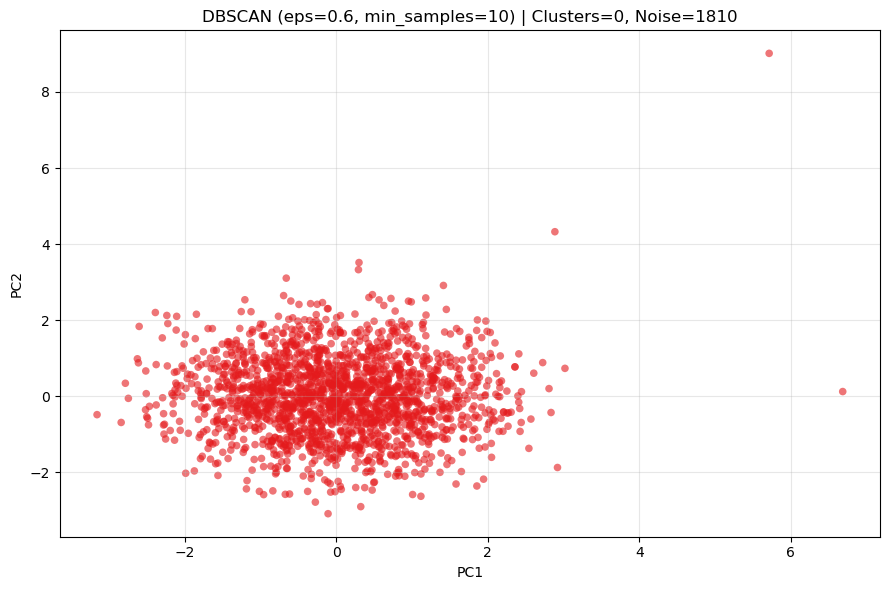

In [36]:
plt.figure(figsize=(9, 6))
plt.scatter(X2_pca[:, 0], X2_pca[:, 1], c=labels_db2,
            cmap='Set1', alpha=0.6, s=30, edgecolors='none')
plt.title(f'DBSCAN (eps=0.6, min_samples=10) | Clusters={n_clusters_db}, Noise={n_noise_db}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('lab2_dbscan.png', dpi=120); 
plt.show()

In [37]:
#k-Means sweep
sweep_results = []
for k in range(2, 7):
    km_s = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X2_s)
    lbl  = km_s.labels_
    sil  = silhouette_score(X2_s, lbl)
    sweep_results.append({'k': k, 'inertia': km_s.inertia_, 'silhouette': sil})

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

 k      inertia  silhouette
 2 14829.478791    0.090558
 3 13767.751077    0.091640
 4 13055.422699    0.084589
 5 12478.395993    0.085990
 6 12029.977970    0.084101


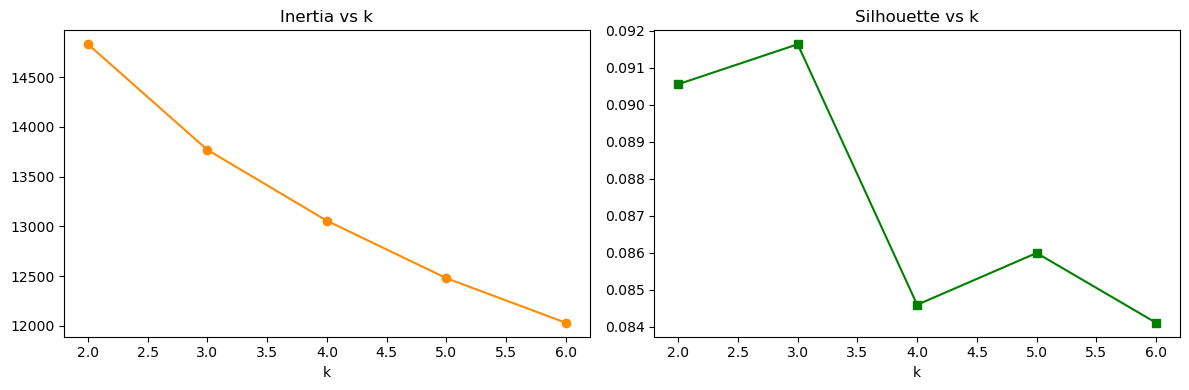

In [38]:
ig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sweep_df['k'], sweep_df['inertia'], marker='o', color='darkorange')
axes[0].set_title('Inertia vs k'); axes[0].set_xlabel('k')
axes[1].plot(sweep_df['k'], sweep_df['silhouette'], marker='s', color='green')
axes[1].set_title('Silhouette vs k'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.savefig('lab2_sweep.png', dpi=120); 
plt.show()

<h1>Step 3:Association Rule Mining: Apriori</h1>

In [39]:
#Step1: Building transaction list from survey responses
from itertools import combinations
from collections import Counter

In [40]:
def make_transaction(row):
    items = []
    items.append('EMPLOY_' + str(row['Employment_Status']).strip().replace(' ', '_'))
    items.append('CITY_'   + str(row['City']).strip().replace(' ', '_'))
    items.append('AGE_'    + str(row['Age_Group']).strip().replace(' ', '_'))
    items.append('BURDEN_' + str(row['Burden_Category']).strip().replace(' ', '_'))
    items.append('DRIVER_' + str(row['Cost_Driver']).strip().replace(' ', '_').replace('(','').replace(')',''))

# Coping measures (multi-value, semicolon-separated)
    for m in str(row['Coping_Measures']).split(';'):
        m2 = m.strip().replace(' ','_')
        if m2 and m2 != 'nan':
            items.append('COPE_' + m2[:25])
    if str(row['Has_Insurance']) == 'Yes':
        items.append('HAS_INSURANCE')
    if str(row['Skipped_Medical']) != 'No':
        items.append('SKIPPED_MEDICAL')
    if str(row['Reduced_Food']) != 'No':
        items.append('REDUCED_FOOD')
    return [i.replace('/','_').replace('\\','_') for i in items]

transactions3 = df_raw.apply(make_transaction, axis=1).tolist()
all_items3    = [item for t in transactions3 for item in t]
item_freq3    = Counter(all_items3)
n_trans3      = len(transactions3)

freq_df3 = pd.DataFrame(item_freq3.items(), columns=['item','count'])
freq_df3 = freq_df3.sort_values('count', ascending=False)
print(f'Total transactions: {n_trans3}')
print(f'Unique items: {len(item_freq3)}')
print('\nTop 15 items:')
print(freq_df3.head(15).to_string(index=False))

Total transactions: 1810
Unique items: 40

Top 15 items:
                          item  count
                  REDUCED_FOOD   1391
               SKIPPED_MEDICAL   1234
                 HAS_INSURANCE    874
COPE_Relocated_to_a_cheaper_ar    736
         COPE_Reduced_spending    723
           COPE_Borrowed_money    709
 COPE_Started_a_small_business    707
      COPE_Taking_a_second_job    673
                EMPLOY_Student    470
          EMPLOY_Self-employed    460
             EMPLOY_Unemployed    443
               EMPLOY_Employed    437
                AGE_56_-_above    421
DRIVER_Inflation_rising_prices    382
    DRIVER_Government_policies    369


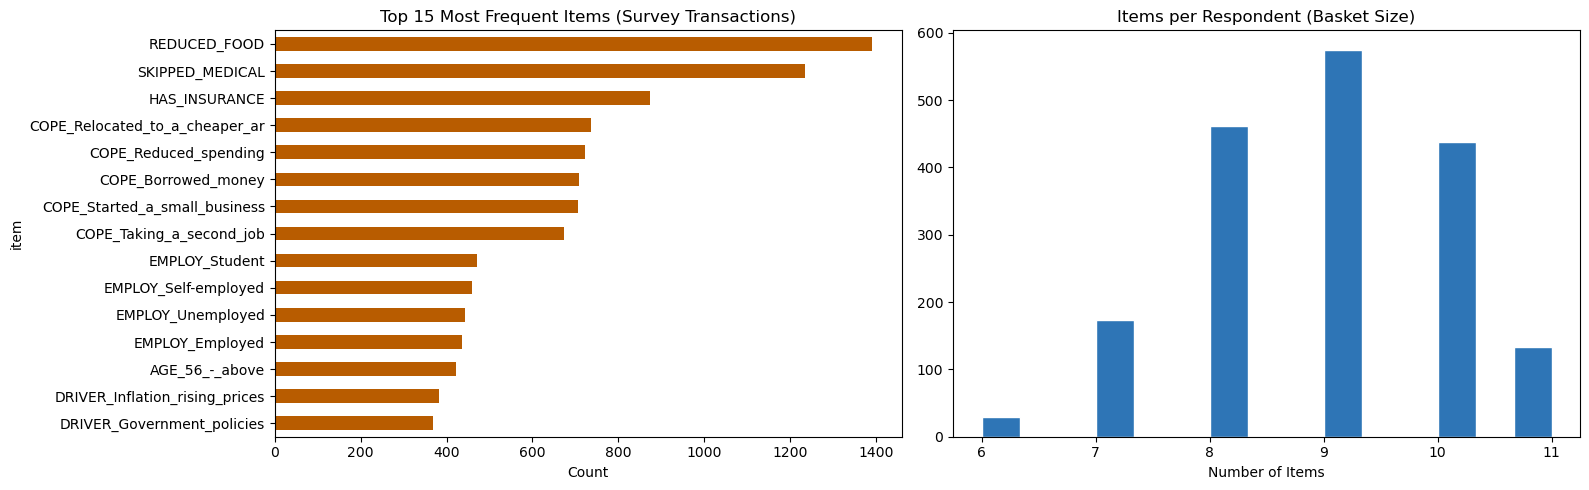

In [41]:
#Step2: Item frequency bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
freq_df3.head(15).sort_values('count').plot(
    kind='barh', x='item', y='count', ax=axes[0], color='#B85C00', legend=False)
axes[0].set_title('Top 15 Most Frequent Items (Survey Transactions)')
axes[0].set_xlabel('Count')

basket_sizes = [len(t) for t in transactions3]
axes[1].hist(basket_sizes, bins=15, color='#2E75B6', edgecolor='white')
axes[1].set_title('Items per Respondent (Basket Size)')
axes[1].set_xlabel('Number of Items')
plt.tight_layout(); plt.savefig('lab3_freq.png', dpi=120); 
plt.show()

In [42]:
#Step3: One-hot encode for Apriori
unique_items3 = [i for i, c in item_freq3.items() if c >= 5]  # prune rare items
print(f'Items after pruning (min support 5): {len(unique_items3)}')

encoded3 = []
for t in transactions3:
    row3 = {item: (item in t) for item in unique_items3}
    encoded3.append(row3)
df_enc3 = pd.DataFrame(encoded3)
print('Encoded matrix shape:', df_enc3.shape)

Items after pruning (min support 5): 37
Encoded matrix shape: (1810, 37)


In [43]:
#Step4: Single-item support
min_support3 = 0.10
item_support3 = {item: df_enc3[item].sum() / n_trans3 for item in unique_items3}
frequent_1   = {k: v for k, v in item_support3.items() if v >= min_support3}
print(f'Frequent single items (sup>={min_support3}): {len(frequent_1)}')
for item, sup in sorted(frequent_1.items(), key=lambda x: -x[1])[:15]:
    print(f'  {item:40s}  support={sup:.3f}')


Frequent single items (sup>=0.1): 36
  REDUCED_FOOD                              support=0.769
  SKIPPED_MEDICAL                           support=0.682
  HAS_INSURANCE                             support=0.483
  COPE_Relocated_to_a_cheaper_ar            support=0.407
  COPE_Reduced_spending                     support=0.399
  COPE_Borrowed_money                       support=0.392
  COPE_Started_a_small_business             support=0.391
  COPE_Taking_a_second_job                  support=0.372
  EMPLOY_Student                            support=0.260
  EMPLOY_Self-employed                      support=0.254
  EMPLOY_Unemployed                         support=0.245
  EMPLOY_Employed                           support=0.241
  AGE_56_-_above                            support=0.233
  DRIVER_Inflation_rising_prices            support=0.211
  DRIVER_Government_policies                support=0.204


In [44]:
# Step5: Mine association rules from pairs
min_confidence3 = 0.45
pair_support3   = {}
freq_items3     = list(frequent_1.keys())

for a, b in combinations(freq_items3, 2):
    sup = (df_enc3[a] & df_enc3[b]).sum() / n_trans3
    if sup >= min_support3:
        pair_support3[(a, b)] = sup

rules3 = []
for (a, b), sup_ab in pair_support3.items():
    for ant, cons in [(a, b), (b, a)]:
        sup_ant  = item_support3.get(ant, 0)
        conf     = sup_ab / sup_ant if sup_ant > 0 else 0
        sup_cons = item_support3.get(cons, 0)
        lift     = conf / sup_cons if sup_cons > 0 else 0
        if conf >= min_confidence3:
            rules3.append({'antecedent': ant, 'consequent': cons,
                           'support': round(sup_ab, 4),
                           'confidence': round(conf, 4),
                           'lift': round(lift, 4)})

rules_df3 = pd.DataFrame(rules3).sort_values('lift', ascending=False)
print(f'Rules generated (conf>={min_confidence3}): {len(rules_df3)}')
print(rules_df3.head(10).to_string(index=False))

Rules generated (conf>=0.45): 71
                   antecedent      consequent  support  confidence   lift
                    AGE_18-25 SKIPPED_MEDICAL   0.1348      0.7485 1.0978
            BURDEN_Healthcare SKIPPED_MEDICAL   0.1232      0.7384 1.0831
                  CITY_Douala SKIPPED_MEDICAL   0.1039      0.7344 1.0772
               AGE_56_-_above   HAS_INSURANCE   0.1193      0.5131 1.0625
                 CITY_Bamenda    REDUCED_FOOD   0.1083      0.8099 1.0539
        BURDEN_Transportation SKIPPED_MEDICAL   0.1099      0.7158 1.0500
COPE_Started_a_small_business SKIPPED_MEDICAL   0.2790      0.7143 1.0477
               EMPLOY_Student   HAS_INSURANCE   0.1304      0.5021 1.0399
   DRIVER_Government_policies SKIPPED_MEDICAL   0.1442      0.7073 1.0375
COPE_Started_a_small_business   HAS_INSURANCE   0.1945      0.4979 1.0311


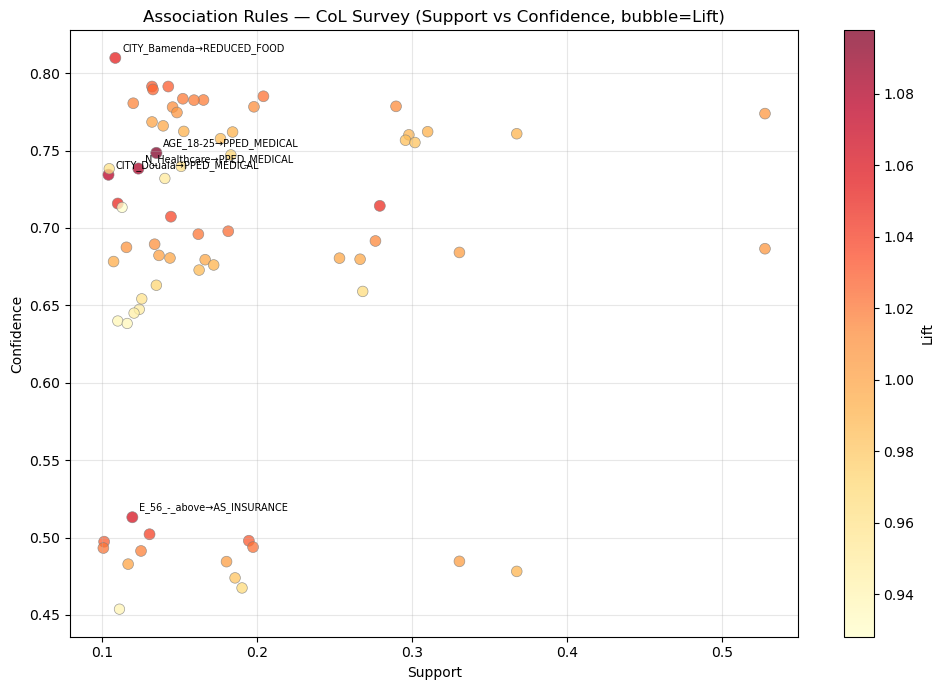

In [45]:
#Step6: Support vs Confidence bubble chart
if len(rules_df3) > 0:
    plt.figure(figsize=(10, 7))
    sc3 = plt.scatter(rules_df3['support'], rules_df3['confidence'],
                      c=rules_df3['lift'], cmap='YlOrRd',
                      s=rules_df3['lift'] * 60, alpha=0.75,
                      edgecolors='grey', linewidth=0.5)
    plt.colorbar(sc3, label='Lift')
    for _, row in rules_df3.head(5).iterrows():
        label = f"{row['antecedent'][-12:]}→{row['consequent'][-12:]}"
        plt.annotate(label, (row['support'], row['confidence']),
                     fontsize=7, xytext=(5, 5), textcoords='offset points')
    plt.xlabel('Support'); plt.ylabel('Confidence')
    plt.title('Association Rules — CoL Survey (Support vs Confidence, bubble=Lift)')
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig('lab3_rules_scatter.png', dpi=120); plt.show()
else:
    print('No rules generated — try lowering min_support or min_confidence.')


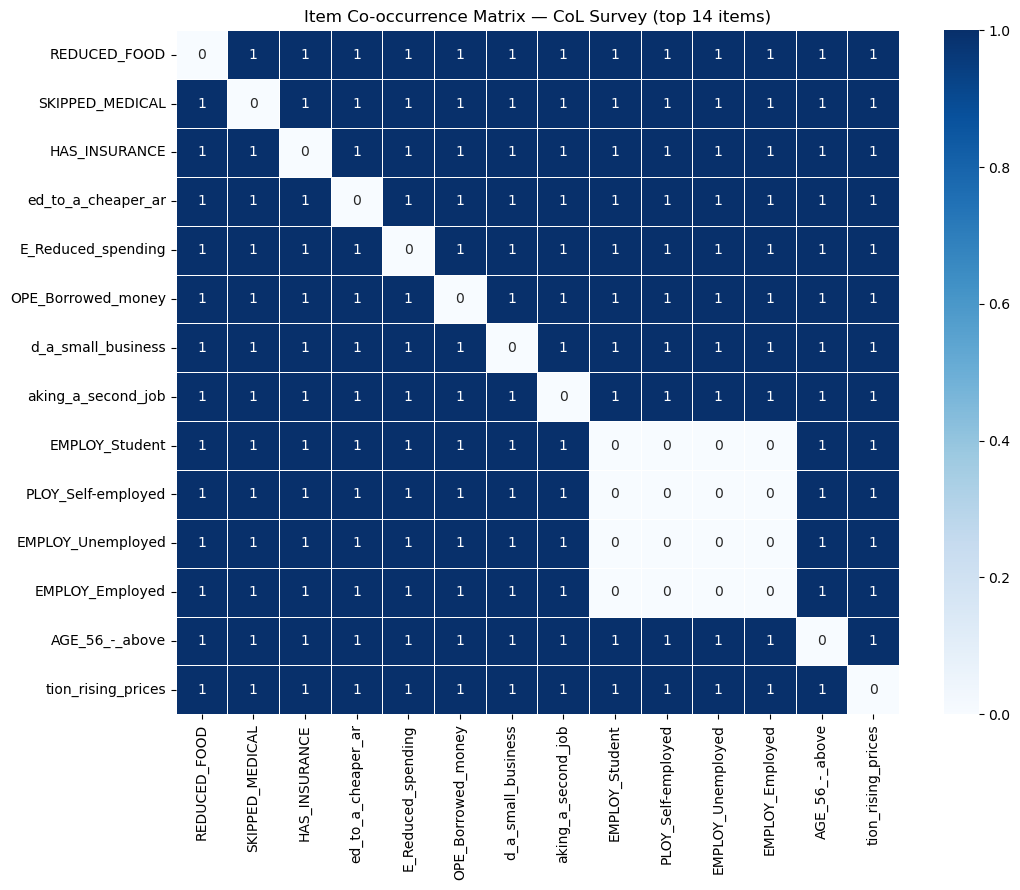

In [46]:
# ── Step 7 · Co-occurrence heatmap (top burden/driver items) ──────────────
top_items3 = [i for i in freq_df3.head(14)['item'] if i in df_enc3.columns]
cooc3 = df_enc3[top_items3].T.dot(df_enc3[top_items3]).astype(int)
np.fill_diagonal(cooc3.values, 0)

plt.figure(figsize=(11, 9))
sns.heatmap(cooc3, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white',
            xticklabels=[i[-18:] for i in top_items3],
            yticklabels=[i[-18:] for i in top_items3])
plt.title('Item Co-occurrence Matrix — CoL Survey (top 14 items)')
plt.tight_layout(); plt.savefig('lab3_cooccurrence.png', dpi=120); 
plt.show()

<h1>Step 4:Regression & Prediction</h1>

In [47]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
#Step 1: Prepare features
feat_lab4 = ['Employment_Status_enc','Education_Level_enc','Age_Group_enc',
             'City_enc','Income_Numeric','Household_Size','Food_Pct_Num',
             'Rent_Pct_Num','Utilities_XAF','Fuel_Impact','Transport_Trips',
             'School_Cost_Scale','Healthcare_Spend']

X4 = df[feat_lab4].fillna(0)
y4 = df['Rent_XAF'].fillna(df['Rent_XAF'].median())


In [49]:
# Remove extreme outliers (top 1%)
q99 = y4.quantile(0.99)
mask4 = y4 <= q99
X4, y4 = X4[mask4], y4[mask4]
print(f'Regression dataset: {X4.shape}  Target range: {y4.min():.0f} – {y4.max():.0f} XAF')

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.20, random_state=42)

sc4 = StandardScaler()
X4_train_s = sc4.fit_transform(X4_train)
X4_test_s  = sc4.transform(X4_test)

Regression dataset: (1791, 13)  Target range: 0 – 252518 XAF


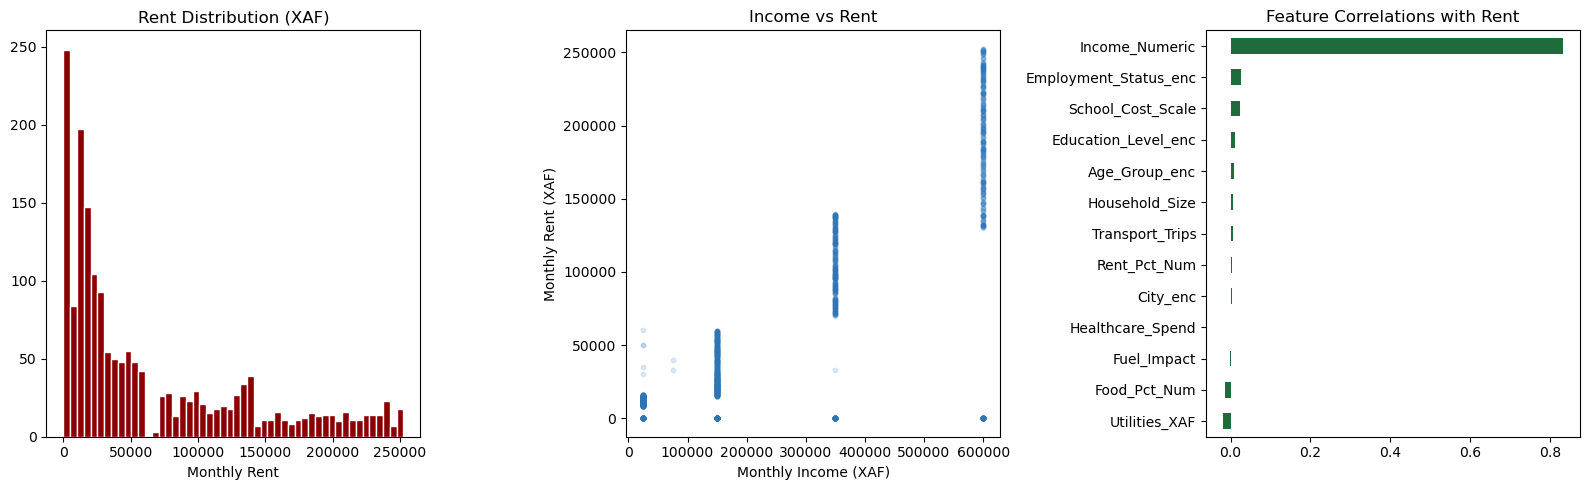

In [50]:
#Step2: EDA
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(y4, bins=50, color='#8B0000', edgecolor='white')
axes[0].set_title('Rent Distribution (XAF)'); axes[0].set_xlabel('Monthly Rent')

axes[1].scatter(df.loc[mask4, 'Income_Numeric'], y4, alpha=0.15, s=10, color='#2E75B6')
axes[1].set_xlabel('Monthly Income (XAF)'); axes[1].set_ylabel('Monthly Rent (XAF)')
axes[1].set_title('Income vs Rent')

corr4 = X4.join(y4.rename('Rent')).corr()['Rent'].drop('Rent').sort_values()
corr4.plot(kind='barh', ax=axes[2], color='#1E6B3C')
axes[2].set_title('Feature Correlations with Rent')
plt.tight_layout(); plt.savefig('lab4_eda.png', dpi=120); 
plt.show()

In [51]:
#Step3: Train & compare models
models4 = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}
results4 = {}
for name, model in models4.items():
    model.fit(X4_train_s, y4_train)
    y_pred4  = model.predict(X4_test_s)
    mae4  = mean_absolute_error(y4_test, y_pred4)
    rmse4 = np.sqrt(mean_squared_error(y4_test, y_pred4))
    r24   = r2_score(y4_test, y_pred4)
    results4[name] = {'model': model, 'y_pred': y_pred4, 'MAE': mae4, 'RMSE': rmse4, 'R2': r24}
    print(f'{name:25s}  MAE={mae4:,.0f}  RMSE={rmse4:,.0f}  R²={r24:.4f}')

Linear Regression          MAE=24,678  RMSE=38,926  R²=0.6947
Ridge (alpha=1.0)          MAE=24,676  RMSE=38,926  R²=0.6947
Random Forest              MAE=24,443  RMSE=41,373  R²=0.6551


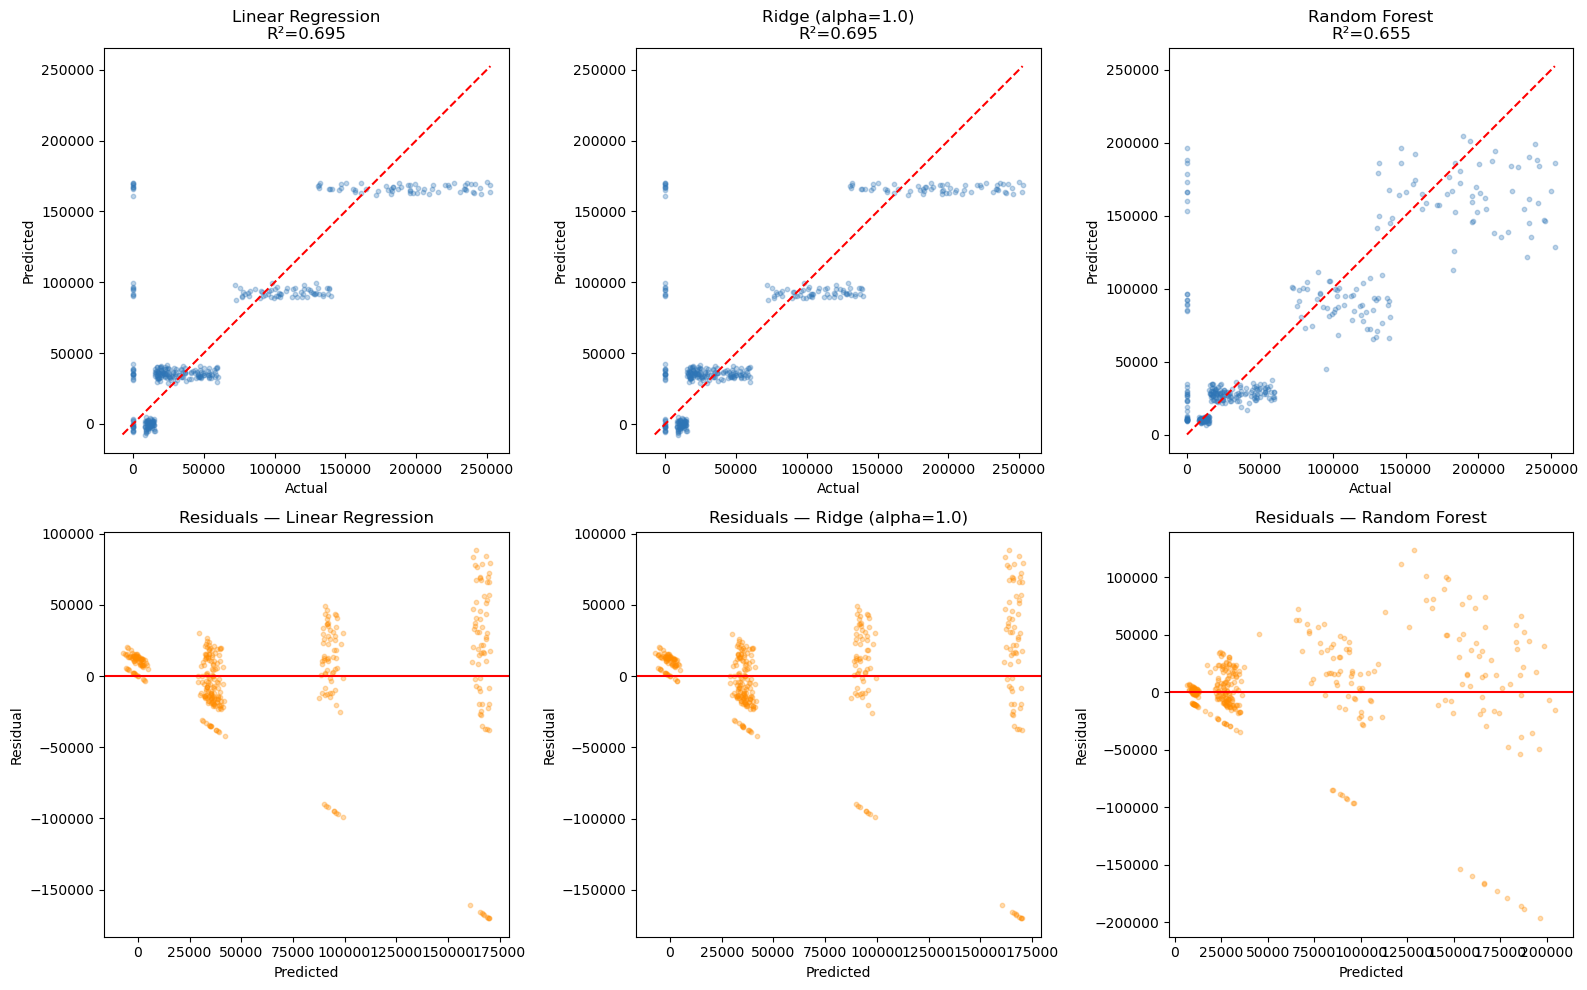

In [52]:
#Step4: Actual vs Predicted + Residuals
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for idx, (name, res) in enumerate(results4.items()):
    ax_top = axes[0, idx]; ax_bot = axes[1, idx]
    ax_top.scatter(y4_test, res['y_pred'], alpha=0.3, s=10, color='#2E75B6')
    lims = [min(y4_test.min(), res['y_pred'].min()),
            max(y4_test.max(), res['y_pred'].max())]
    ax_top.plot(lims, lims, 'r--', linewidth=1.5)
    ax_top.set_title(f"{name}\nR²={res['R2']:.3f}")
    ax_top.set_xlabel('Actual'); ax_top.set_ylabel('Predicted')
    residuals4 = y4_test.values - res['y_pred']
    ax_bot.scatter(res['y_pred'], residuals4, alpha=0.3, s=10, color='darkorange')
    ax_bot.axhline(0, color='red', linewidth=1.5)
    ax_bot.set_title(f'Residuals — {name}')
    ax_bot.set_xlabel('Predicted'); ax_bot.set_ylabel('Residual')
plt.tight_layout(); plt.savefig('lab4_regression_results.png', dpi=120); 
plt.show()

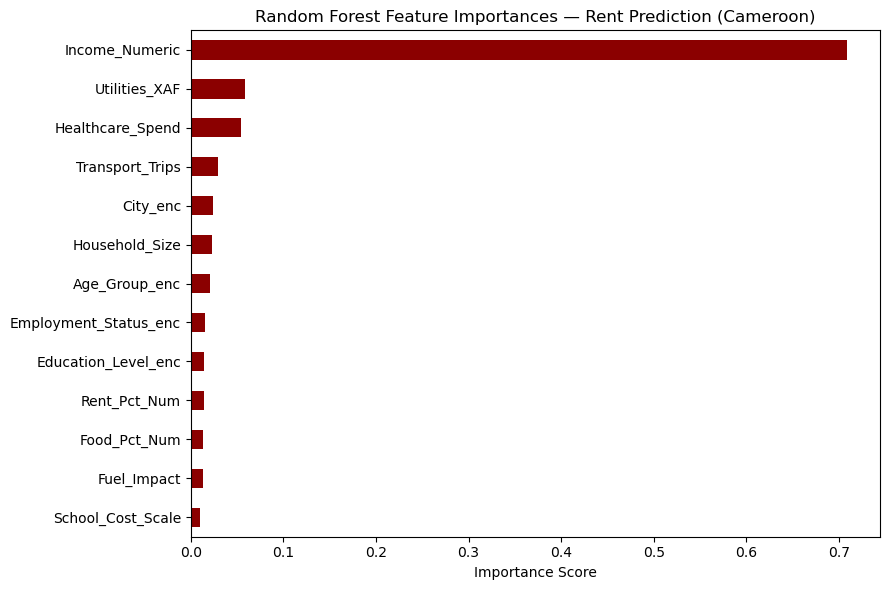

Top 5 predictors of rent:
Income_Numeric      0.708943
Utilities_XAF       0.058834
Healthcare_Spend    0.054039
Transport_Trips     0.029777
City_enc            0.023559


In [53]:
#Step5: Feature importance (Random Forest)
rf4 = results4['Random Forest']['model']
feat_imp4 = pd.Series(rf4.feature_importances_, index=feat_lab4).sort_values()
feat_imp4.plot(kind='barh', figsize=(9, 6), color='#8B0000')
plt.title('Random Forest Feature Importances — Rent Prediction (Cameroon)')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.savefig('lab4_feature_importance.png', dpi=120); 
plt.show()
print('Top 5 predictors of rent:')
print(feat_imp4.nlargest(5).to_string())

<h1>Step 5:Hardship Escalation Prediction (analogue of Customer Churn)</h1>

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.utils import resample

In [55]:
#Step1: Inspect target
print(df_raw['Skipped_Medical'].value_counts())

Skipped_Medical
Yes, more than once    637
Yes, once              597
No                     576
Name: count, dtype: int64


In [56]:
#Step2: Binary encode target
df['Skipped_Medical_bin'] = (df_raw['Skipped_Medical'] != 'No').astype(int)
print('Skipped medical (1=Yes):', df['Skipped_Medical_bin'].value_counts().to_dict())
print('Positive rate:', df['Skipped_Medical_bin'].mean().round(4))

Skipped medical (1=Yes): {1: 1234, 0: 576}
Positive rate: 0.6818


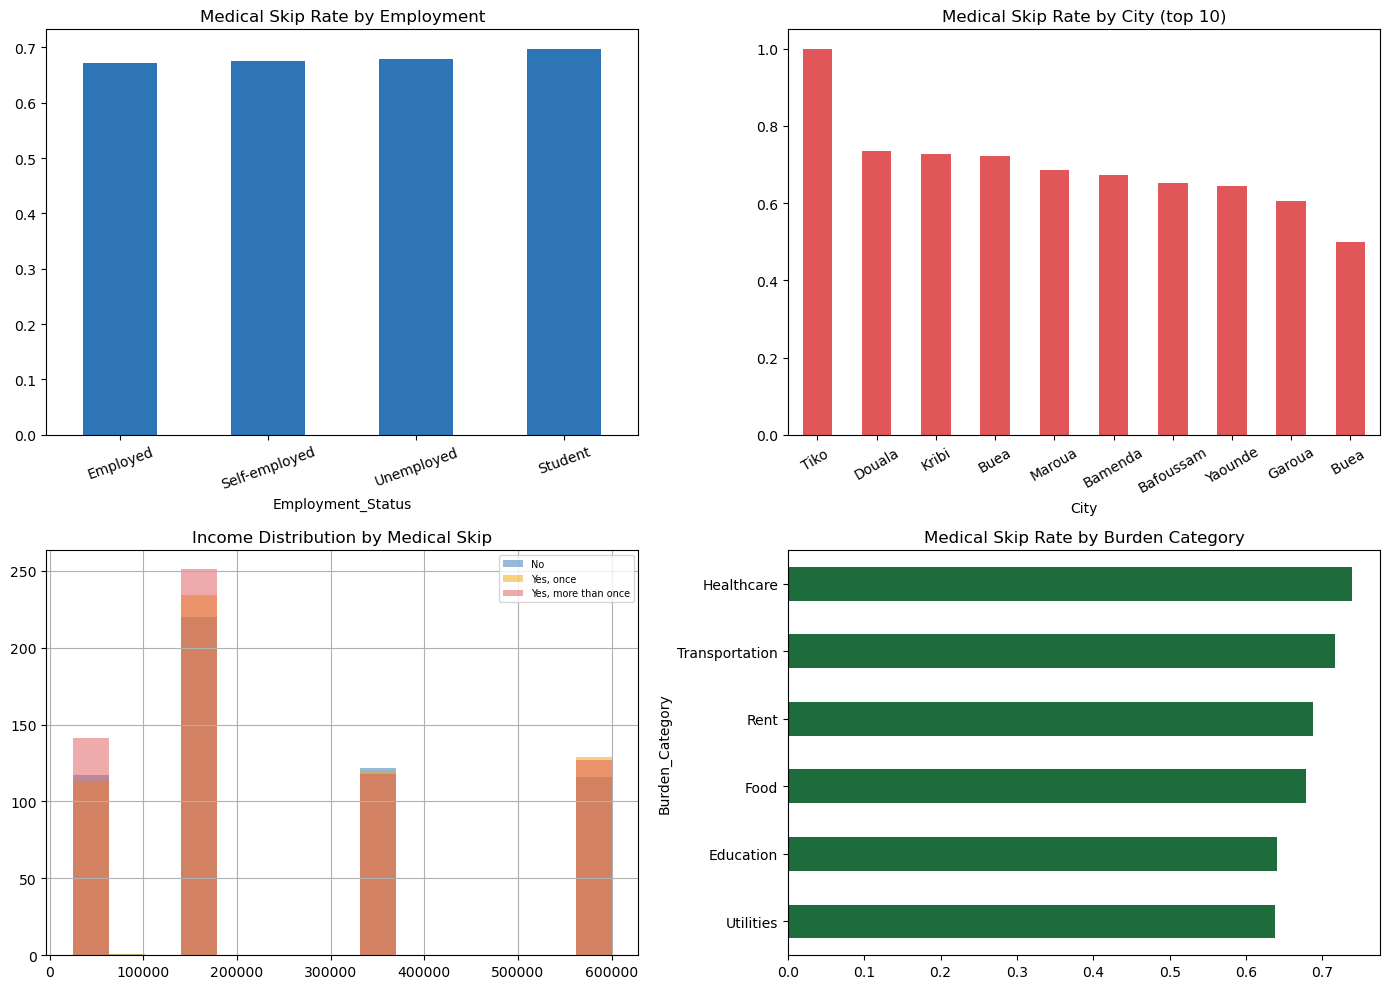

In [57]:
#Step3: EDA — hardship by key factors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_raw.groupby('Employment_Status').apply(
    lambda x: (x['Skipped_Medical'] != 'No').mean()
).sort_values().plot(kind='bar', ax=axes[0, 0], color='#2E75B6', rot=20)
axes[0, 0].set_title('Medical Skip Rate by Employment')

df_raw.groupby('City').apply(
    lambda x: (x['Skipped_Medical'] != 'No').mean()
).sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[0, 1], color='#E15759', rot=30)
axes[0, 1].set_title('Medical Skip Rate by City (top 10)')

for v, col in [('No','#2E75B6'), ('Yes, once','#F0A500'), ('Yes, more than once','#E15759')]:
    sub = df_raw[df_raw['Skipped_Medical'] == v]['Income_Numeric'] if v == 'No' else           df_raw[df_raw['Skipped_Medical'] == v]['Income_Numeric'] if hasattr(df_raw, 'Income_Numeric') else pd.Series()
    mask_med = df_raw['Skipped_Medical'] == v
    df.loc[mask_med, 'Income_Numeric'].hist(bins=15, alpha=0.5, ax=axes[1, 0],
                                            color=col, label=v)
axes[1, 0].set_title('Income Distribution by Medical Skip'); axes[1, 0].legend(fontsize=7)

df_raw.groupby('Burden_Category').apply(
    lambda x: (x['Skipped_Medical'] != 'No').mean()
).sort_values().plot(kind='barh', ax=axes[1, 1], color='#1E6B3C')
axes[1, 1].set_title('Medical Skip Rate by Burden Category')

plt.tight_layout(); plt.savefig('lab5_eda.png', dpi=120); 
plt.show()

In [58]:
#Step4: Preprocess + handle imbalance
feat_lab5 = feat_cols_lab1 + ['Rent_Pct_Num','Rent_XAF','Utilities_XAF','Healthcare_Spend']
X5 = df[feat_lab5].fillna(0)
y5 = df['Skipped_Medical_bin']

In [59]:
X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.20, random_state=42, stratify=y5)

In [60]:
sc5 = StandardScaler()
X5_train_s = sc5.fit_transform(X5_train)
X5_test_s  = sc5.transform(X5_test)

In [61]:
# Oversample minority
X5_min = X5_train_s[y5_train == 1]
y5_min = y5_train[y5_train == 1]
X5_maj = X5_train_s[y5_train == 0]
y5_maj = y5_train[y5_train == 0]

X5_min_up, y5_min_up = resample(X5_min, y5_min, replace=True,
                                  n_samples=len(y5_maj), random_state=42)
X5_bal = np.vstack([X5_maj, X5_min_up])
y5_bal = np.concatenate([y5_maj, y5_min_up])
print('Balanced training set:', dict(zip(*np.unique(y5_bal, return_counts=True))))

Balanced training set: {0: 461, 1: 461}


In [62]:
#Step5: Train classifiers
from sklearn.metrics import classification_report

In [63]:
models5 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
}
results5 = {}
for name, model in models5.items():
    model.fit(X5_bal, y5_bal)
    y5_pred  = model.predict(X5_test_s)
    y5_proba = model.predict_proba(X5_test_s)[:, 1]
    auc5     = roc_auc_score(y5_test, y5_proba)
    results5[name] = {'y_pred': y5_pred, 'y_proba': y5_proba, 'auc': auc5, 'model': model}
    print(f'\n=== {name} (AUC={auc5:.4f}) ===')
    print(classification_report(y5_test, y5_pred, target_names=['No Skip', 'Skipped']))


=== Logistic Regression (AUC=0.5528) ===
              precision    recall  f1-score   support

     No Skip       0.37      0.57      0.45       115
     Skipped       0.73      0.55      0.63       247

    accuracy                           0.56       362
   macro avg       0.55      0.56      0.54       362
weighted avg       0.62      0.56      0.57       362


=== Random Forest (AUC=0.5307) ===
              precision    recall  f1-score   support

     No Skip       0.32      0.70      0.44       115
     Skipped       0.69      0.31      0.43       247

    accuracy                           0.43       362
   macro avg       0.51      0.51      0.43       362
weighted avg       0.57      0.43      0.43       362



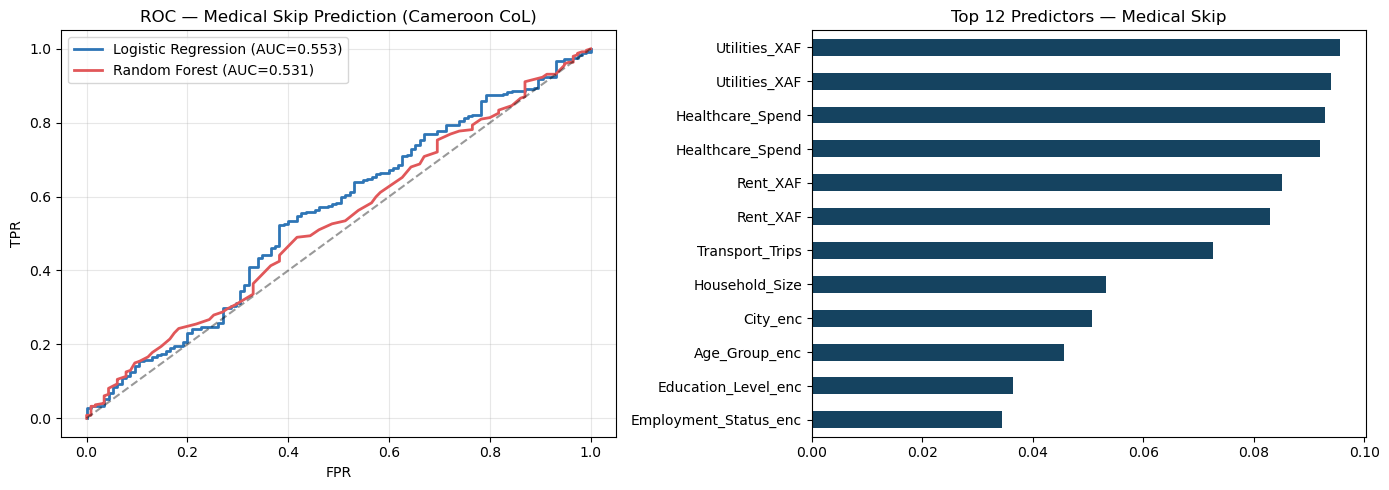

In [64]:
#Step6: ROC curve + feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors5 = ['#2E75B6', '#E15759']
for (name, res), col in zip(results5.items(), colors5):
    fpr5, tpr5, _ = roc_curve(y5_test, res['y_proba'])
    axes[0].plot(fpr5, tpr5, label=f"{name} (AUC={res['auc']:.3f})", color=col, lw=2)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — Medical Skip Prediction (Cameroon CoL)')
axes[0].legend(); axes[0].grid(alpha=0.3)

rf5 = results5['Random Forest']['model']
fi5 = pd.Series(rf5.feature_importances_, index=feat_lab5).nlargest(12).sort_values()
fi5.plot(kind='barh', ax=axes[1], color='#154360')
axes[1].set_title('Top 12 Predictors — Medical Skip')
plt.tight_layout(); plt.savefig('lab5_roc_importance.png', dpi=120); 
plt.show()

<h1>Step 6:NLP / Text Feature Analysis</h1>

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier
import re, string

In [66]:
#Step 1: Explore the food item text column
print('Unique food items (top 20):')
print(df_raw['Top_Food_Item'].value_counts().head(20).to_string())

Unique food items (top 20):
Top_Food_Item
Rice                   345
Fish / Meat            306
Onions & Tomatoes      295
Cooking oil            289
Plantains / Cassava    288
Bread                  279
Eggs                     2
Indomie                  1
Groundnut oil            1
Grandnut oil             1
Plantain                 1
Garri                    1
Perishable items         1


In [67]:
#Step2: Build target: did they reduce food?
def reduced_food_binary(v):
    v = str(v).lower()
    return 0 if v == 'no' else 1

df['Reduced_Food_bin'] = df_raw['Reduced_Food'].apply(reduced_food_binary)
print('Reduced food:', df['Reduced_Food_bin'].value_counts().to_dict())
print('Positive rate:', df['Reduced_Food_bin'].mean().round(4))

Reduced food: {1: 1391, 0: 419}
Positive rate: 0.7685


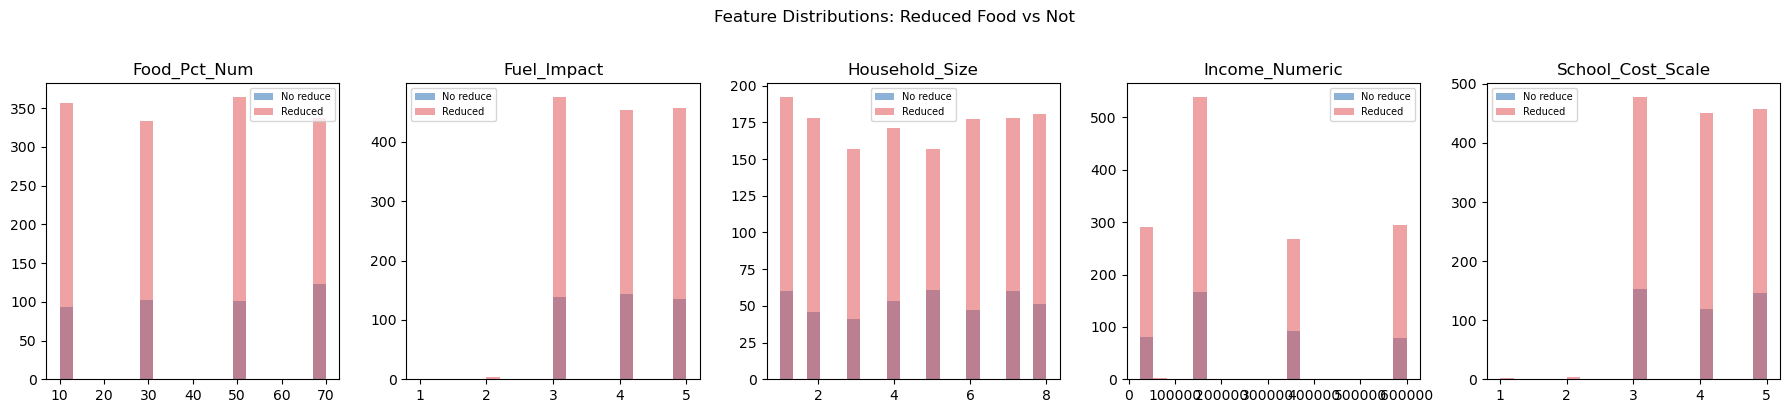

In [68]:
#Step3:EDA — numeric features vs food reduction
feat_lab6_struct = ['Food_Pct_Num','Fuel_Impact','Household_Size',
                    'Income_Numeric','School_Cost_Scale']
fig, axes = plt.subplots(1, len(feat_lab6_struct), figsize=(18, 4))
for ax, col in zip(axes, feat_lab6_struct):
    for lbl, color in [(0, '#2E75B6'), (1, '#E15759')]:
        vals = df[df['Reduced_Food_bin'] == lbl][col].dropna()
        ax.hist(vals, bins=20, alpha=0.55, color=color,
                label='No reduce' if lbl == 0 else 'Reduced')
    ax.set_title(col); ax.legend(fontsize=7)
plt.suptitle('Feature Distributions: Reduced Food vs Not', y=1.02)
plt.tight_layout(); plt.savefig('lab6_eda.png', dpi=120); 
plt.show()

In [69]:
#Approach A · Structured feature classifier
from sklearn.ensemble import RandomForestClassifier as RFC

In [70]:
df['Food_item_enc'] = LabelEncoder().fit_transform(df_raw['Top_Food_Item'].astype(str))
feat_A = feat_lab6_struct + ['Food_item_enc',
         'Employment_Status_enc','City_enc','Age_Group_enc']
X6A = df[feat_A].fillna(0)
y6  = df['Reduced_Food_bin']

In [71]:
X6A_tr, X6A_te, y6_tr, y6_te = train_test_split(
    X6A, y6, test_size=0.2, random_state=42, stratify=y6)
sc6A = StandardScaler()
X6A_tr_s = sc6A.fit_transform(X6A_tr); X6A_te_s = sc6A.transform(X6A_te)

In [72]:
for name6, clf6 in [('Logistic Regression', LogisticRegression(max_iter=500)),
                    ('Random Forest',       RFC(n_estimators=100, random_state=42)),
                    ('Naive Bayes',         GaussianNB())]:
    clf6.fit(X6A_tr_s, y6_tr)
    pred6 = clf6.predict(X6A_te_s)
    print(f'\n=== Approach A — {name6} ===')
    print(classification_report(y6_te, pred6, target_names=['No Reduce','Reduced']))


=== Approach A — Logistic Regression ===
              precision    recall  f1-score   support

   No Reduce       0.00      0.00      0.00        84
     Reduced       0.77      1.00      0.87       278

    accuracy                           0.77       362
   macro avg       0.38      0.50      0.43       362
weighted avg       0.59      0.77      0.67       362


=== Approach A — Random Forest ===
              precision    recall  f1-score   support

   No Reduce       0.50      0.05      0.09        84
     Reduced       0.77      0.99      0.87       278

    accuracy                           0.77       362
   macro avg       0.64      0.52      0.48       362
weighted avg       0.71      0.77      0.69       362


=== Approach A — Naive Bayes ===
              precision    recall  f1-score   support

   No Reduce       0.00      0.00      0.00        84
     Reduced       0.77      1.00      0.87       278

    accuracy                           0.77       362
   macro avg    

In [73]:
#Approach B. TF-IDF on food item text
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['clean_food'] = df_raw['Top_Food_Item'].apply(clean_text)
X6B_tr_raw, X6B_te_raw, y6B_tr, y6B_te = train_test_split(
    df['clean_food'], y6, test_size=0.2, random_state=42, stratify=y6)

tfidf6 = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X6B_tr_tf = tfidf6.fit_transform(X6B_tr_raw)
X6B_te_tf = tfidf6.transform(X6B_te_raw)
print('TF-IDF shape:', X6B_tr_tf.shape)

for name6b, clf6b in [('Multinomial NB',    MultinomialNB(alpha=0.1)),
                       ('Logistic (TF-IDF)', LogisticRegression(max_iter=500)),
                       ('Passive-Aggressive',PassiveAggressiveClassifier(max_iter=500))]:
    clf6b.fit(X6B_tr_tf, y6B_tr)
    pred6b = clf6b.predict(X6B_te_tf)
    print(f'\n=== Approach B (TF-IDF) — {name6b} ===')
    print(classification_report(y6B_te, pred6b, target_names=['No Reduce','Reduced']))

TF-IDF shape: (1448, 25)

=== Approach B (TF-IDF) — Multinomial NB ===
              precision    recall  f1-score   support

   No Reduce       0.00      0.00      0.00        84
     Reduced       0.77      1.00      0.87       278

    accuracy                           0.77       362
   macro avg       0.38      0.50      0.43       362
weighted avg       0.59      0.77      0.67       362


=== Approach B (TF-IDF) — Logistic (TF-IDF) ===
              precision    recall  f1-score   support

   No Reduce       0.00      0.00      0.00        84
     Reduced       0.77      1.00      0.87       278

    accuracy                           0.77       362
   macro avg       0.38      0.50      0.43       362
weighted avg       0.59      0.77      0.67       362


=== Approach B (TF-IDF) — Passive-Aggressive ===
              precision    recall  f1-score   support

   No Reduce       0.21      0.30      0.24        84
     Reduced       0.76      0.65      0.70       278

    accuracy

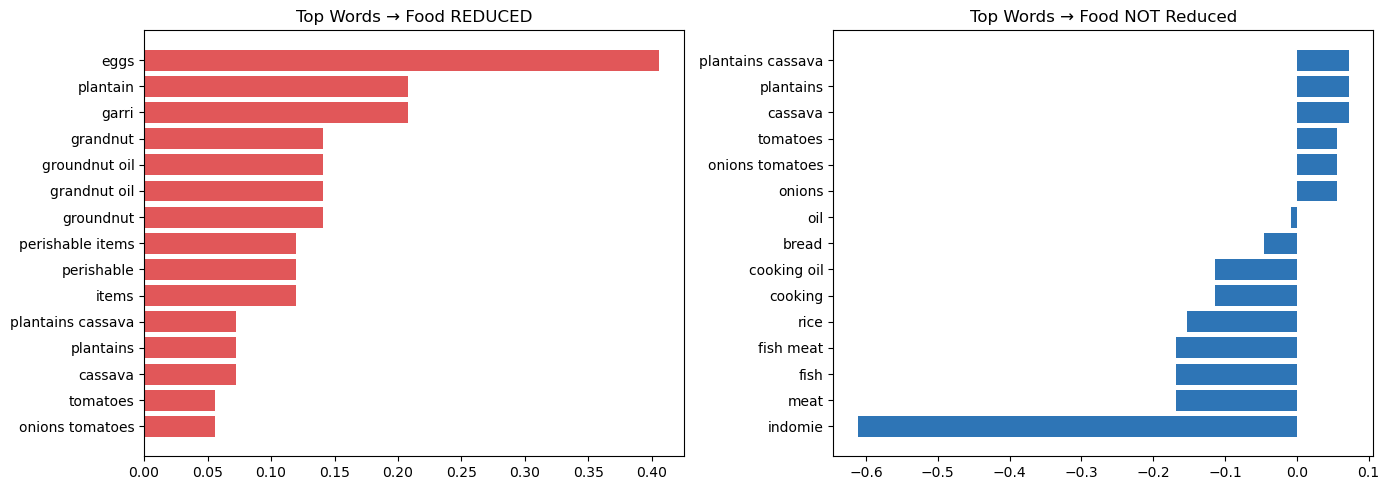

In [74]:
# ── Most discriminative food words ────────────────────────────────────────
lr6b = LogisticRegression(max_iter=500).fit(X6B_tr_tf, y6B_tr)
feat_names6 = tfidf6.get_feature_names_out()
coef6       = lr6b.coef_[0]

fig, axes6 = plt.subplots(1, 2, figsize=(14, 5))
top_reduce   = np.argsort(coef6)[-15:][::-1]
top_no_reduce= np.argsort(coef6)[:15]

axes6[0].barh([feat_names6[i] for i in top_reduce[::-1]], coef6[top_reduce[::-1]], color='#E15759')
axes6[0].set_title('Top Words → Food REDUCED')
axes6[1].barh([feat_names6[i] for i in top_no_reduce], coef6[top_no_reduce], color='#2E75B6')
axes6[1].set_title('Top Words → Food NOT Reduced')
plt.tight_layout(); plt.savefig('lab6_words.png', dpi=120);
plt.show()

<h1>Step 7: Risk Scoring (analogous to Credit Risk)</h1>

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

In [76]:
# ── Step 1 · Build composite risk target ───
df['High_Risk'] = ((df['Skipped_Medical_bin'] == 1) &
                   (df['Reduced_Food_bin'] == 1)).astype(int)
print('High-Risk rate:', df['High_Risk'].mean().round(4))
print(df['High_Risk'].value_counts().to_dict())

High-Risk rate: 0.5276
{1: 955, 0: 855}


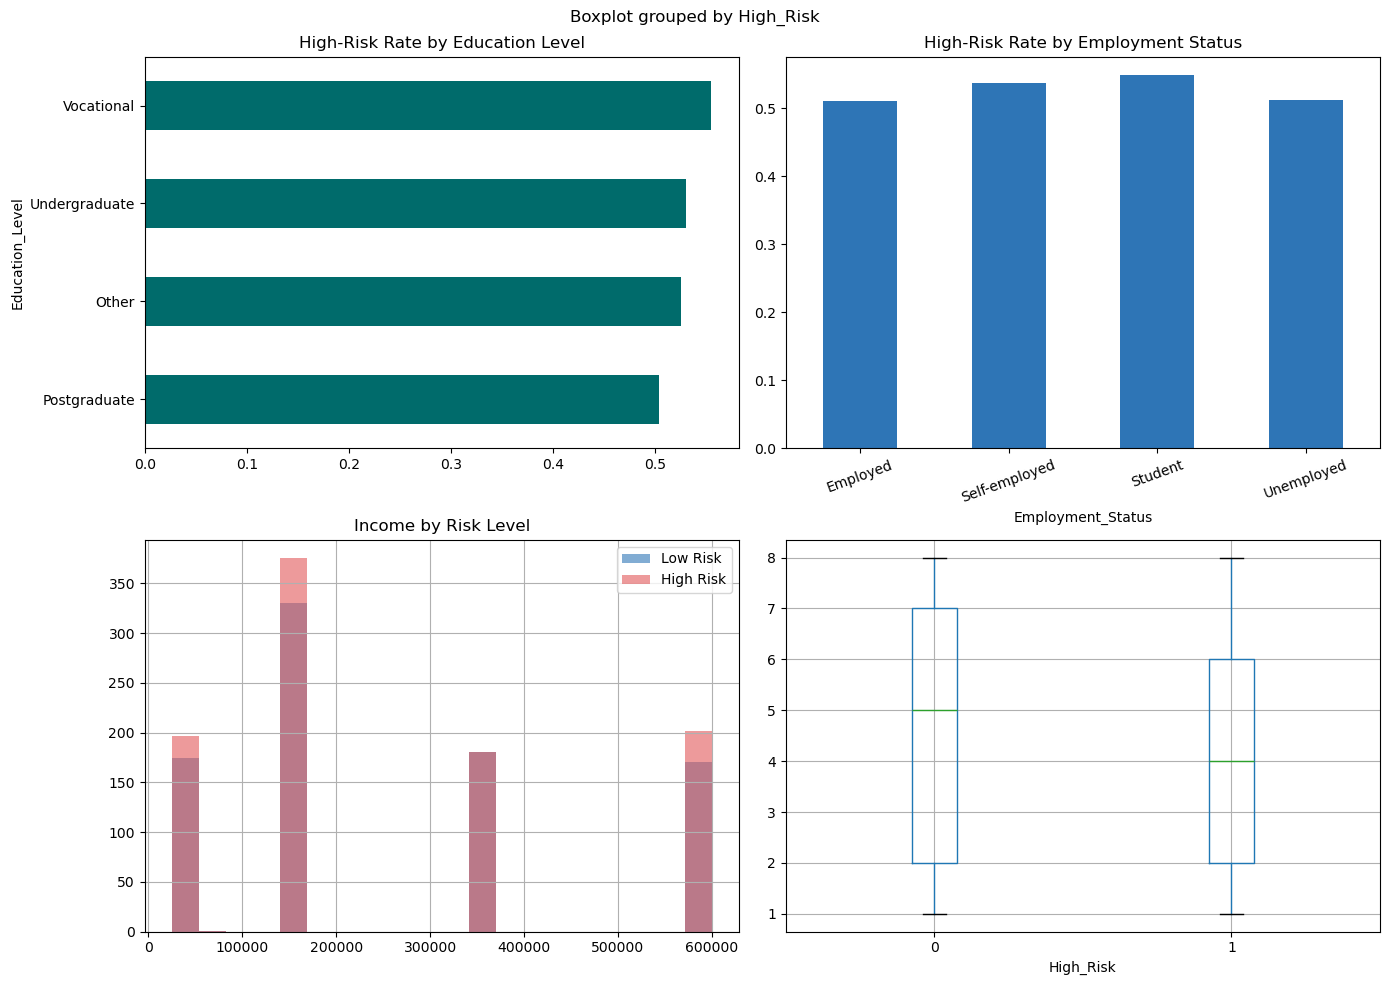

In [77]:
#Step2: EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_raw.groupby('Education_Level').apply(
    lambda x: df.loc[x.index, 'High_Risk'].mean()
).sort_values().plot(kind='barh', ax=axes[0, 0], color='#006B6B')
axes[0, 0].set_title('High-Risk Rate by Education Level')

df_raw.groupby('Employment_Status').apply(
    lambda x: df.loc[x.index, 'High_Risk'].mean()
).plot(kind='bar', ax=axes[0, 1], color='#2E75B6', rot=20)
axes[0, 1].set_title('High-Risk Rate by Employment Status')

for d, col in [(0, '#2E75B6'), (1, '#E15759')]:
    df[df['High_Risk'] == d]['Income_Numeric'].hist(
        bins=20, alpha=0.6, ax=axes[1, 0], color=col,
        label='Low Risk' if d == 0 else 'High Risk')
axes[1, 0].set_title('Income by Risk Level'); axes[1, 0].legend()

df.boxplot(column='Household_Size', by='High_Risk', ax=axes[1, 1])
axes[1, 1].set_title('Household Size by Risk'); plt.sca(axes[1, 1]); plt.title('')
plt.tight_layout(); plt.savefig('lab7_eda.png', dpi=120); 
plt.show()

In [78]:
#Step3: Preprocess & balance
feat_lab7 = feat_lab5 
X7 = df[feat_lab7].fillna(0)
y7 = df['High_Risk']

In [79]:
X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7, test_size=0.20, random_state=42, stratify=y7)

In [80]:
X7_min = X7_train[y7_train == 1]
y7_min = y7_train[y7_train == 1]
X7_maj = X7_train[y7_train == 0]
y7_maj = y7_train[y7_train == 0]
X7_min_up, y7_min_up = resample(X7_min, y7_min, replace=True,
                                  n_samples=len(y7_maj), random_state=42)
X7_bal = pd.concat([X7_maj, X7_min_up])
y7_bal = pd.concat([y7_maj, y7_min_up])

In [81]:
sc7 = StandardScaler()
X7_tr_s = sc7.fit_transform(X7_bal)
X7_te_s = sc7.transform(X7_test)
print('Balanced set:', y7_bal.value_counts().to_dict())

Balanced set: {0: 684, 1: 684}


In [82]:
#Step4: Train Random Forest + evaluate
rf7 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf7.fit(X7_tr_s, y7_bal)
y7_pred  = rf7.predict(X7_te_s)
y7_proba = rf7.predict_proba(X7_te_s)[:, 1]

In [83]:
auc7 = roc_auc_score(y7_test, y7_proba)
print(f'ROC-AUC: {auc7:.4f}')
print(classification_report(y7_test, y7_pred, target_names=['Low Risk','High Risk']))

ROC-AUC: 0.4708
              precision    recall  f1-score   support

    Low Risk       0.47      0.77      0.58       171
   High Risk       0.52      0.23      0.32       191

    accuracy                           0.48       362
   macro avg       0.50      0.50      0.45       362
weighted avg       0.50      0.48      0.44       362



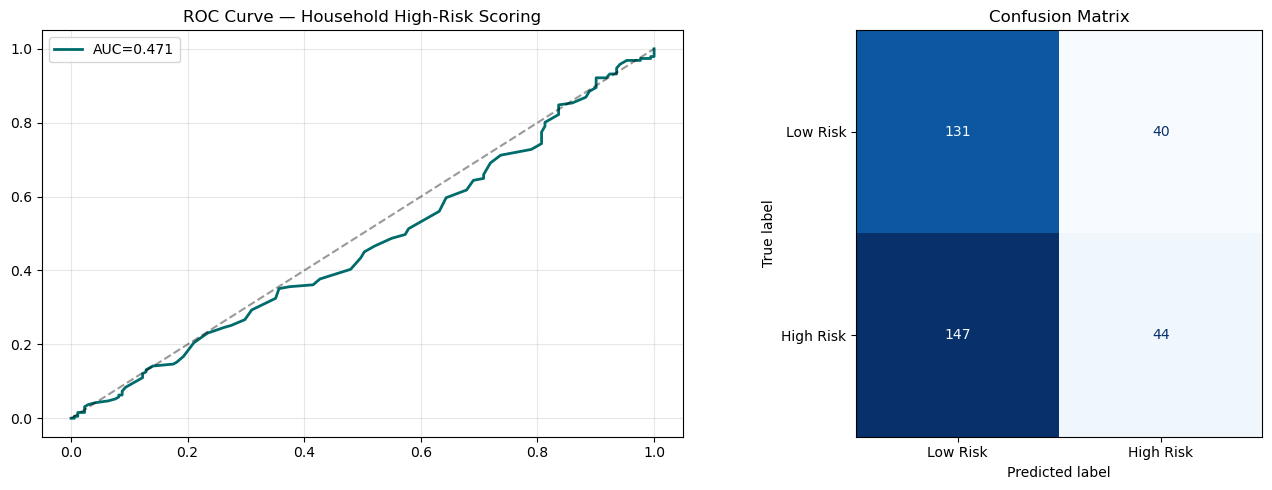

In [84]:
fig, axes7 = plt.subplots(1, 2, figsize=(14, 5))
fpr7, tpr7, _ = roc_curve(y7_test, y7_proba)
axes7[0].plot(fpr7, tpr7, color='#006B6B', lw=2, label=f'AUC={auc7:.3f}')
axes7[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes7[0].set_title('ROC Curve — Household High-Risk Scoring')
axes7[0].legend(); axes7[0].grid(alpha=0.3)

ConfusionMatrixDisplay(confusion_matrix(y7_test, y7_pred),
                       display_labels=['Low Risk','High Risk']).plot(
    ax=axes7[1], cmap='Blues', colorbar=False)
axes7[1].set_title('Confusion Matrix')
plt.tight_layout(); plt.savefig('lab7_roc_cm.png', dpi=120); 
plt.show()

                count  actual_risk_rate  mean_score
tier                                               
High Risk         167             0.497       0.513
Low Risk            7             0.714       0.162
Medium Risk       187             0.551       0.368
Very High Risk      1             0.000       0.725


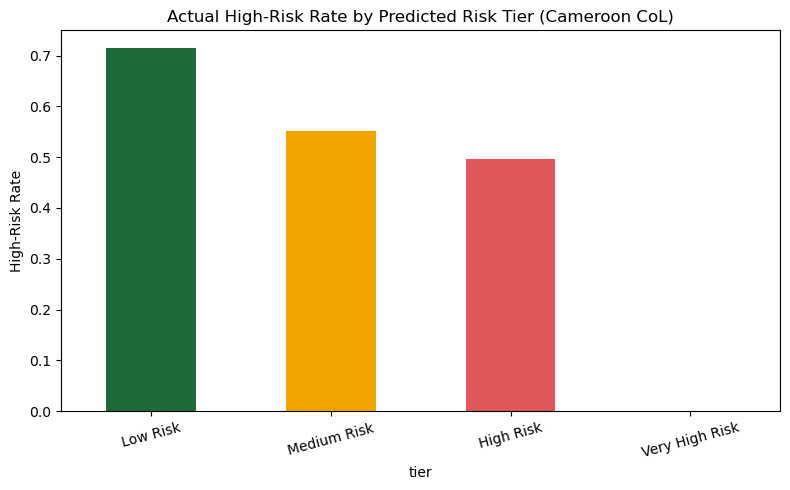

In [85]:
#Step 5: Risk tier segmentation
test7_df = X7_test.copy()
test7_df['true_risk'] = y7_test.values
test7_df['risk_score'] = y7_proba

def risk_tier7(s):
    if s < 0.20:  return 'Low Risk'
    elif s < 0.45: return 'Medium Risk'
    elif s < 0.70: return 'High Risk'
    else:          return 'Very High Risk'

test7_df['tier'] = test7_df['risk_score'].apply(risk_tier7)
summary7 = test7_df.groupby('tier').agg(
    count=('risk_score','count'),
    actual_risk_rate=('true_risk','mean'),
    mean_score=('risk_score','mean')
).round(3)
print(summary7.to_string())

order7 = ['Low Risk','Medium Risk','High Risk','Very High Risk']
summary7.loc[[t for t in order7 if t in summary7.index], 'actual_risk_rate'].plot(
    kind='bar', color=['#1E6B3C','#F0A500','#E15759','#8B0000'],
    rot=15, figsize=(8, 5))
plt.title('Actual High-Risk Rate by Predicted Risk Tier (Cameroon CoL)')
plt.ylabel('High-Risk Rate'); plt.tight_layout()
plt.savefig('lab7_tiers.png', dpi=120); 
plt.show()

<h1>Step 8: Recommendation Engine</h1>

In [86]:
from sklearn.metrics.pairwise import cosine_similarity

In [87]:
#Step 1: Load & explore coping strategies
print('Unique coping measure combinations (top 15):')
print(df_raw['Coping_Measures'].value_counts().head(15).to_string())

Unique coping measure combinations (top 15):
Coping_Measures
Reduced spending                                         138
Started a small business                                 137
Relocated to a cheaper area                              129
Taking a second job                                      126
Borrowed money                                           111
Borrowed money; Reduced spending                          40
Relocated to a cheaper area; Taking a second job          37
Started a small business; Reduced spending                37
Taking a second job; Relocated to a cheaper area          36
Reduced spending; Started a small business                35
Relocated to a cheaper area; Reduced spending             34
Relocated to a cheaper area; Started a small business     33
Reduced spending; Borrowed money                          33
Relocated to a cheaper area; Borrowed money               30
Borrowed money; Started a small business                  29


In [88]:
# ── Step 2 · Parse coping strategies into item lists ─────────────────────
STRATEGIES = [
    'Reduced spending',
    'Taking a second job',
    'Started a small business',
    'Borrowed money',
    'Relocated to a cheaper area',
]

for s in STRATEGIES:
    col_s = 'COPE_' + s.replace(' ','_')
    df[col_s] = df_raw['Coping_Measures'].astype(str).str.contains(s, case=False, na=False).astype(int)
    print(f'{s:35s} → {df[col_s].sum()} respondents ({df[col_s].mean():.1%})')

Reduced spending                    → 723 respondents (39.9%)
Taking a second job                 → 674 respondents (37.2%)
Started a small business            → 707 respondents (39.1%)
Borrowed money                      → 709 respondents (39.2%)
Relocated to a cheaper area         → 736 respondents (40.7%)


In [89]:
#Step 3: Build user-item rating matrix
# "items" = coping strategies; "rating" = 1 if adopted, 0 if not
strategy_cols = ['COPE_' + s.replace(' ','_') for s in STRATEGIES]
cope_matrix   = df[strategy_cols].fillna(0)
print('Coping matrix shape:', cope_matrix.shape)

Coping matrix shape: (1810, 5)


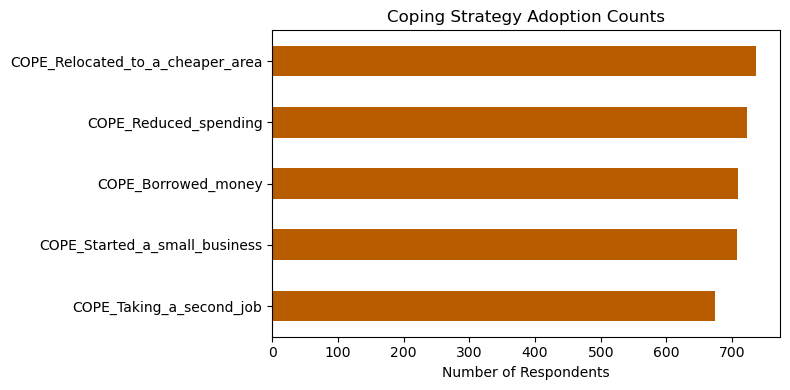

In [90]:
# EDA — strategy popularity
cope_matrix.sum().sort_values(ascending=True).plot(
    kind='barh', figsize=(8, 4), color='#B85C00')
plt.title('Coping Strategy Adoption Counts')
plt.xlabel('Number of Respondents')
plt.tight_layout(); plt.savefig('lab8_strategy_counts.png', dpi=120); 
plt.show()

In [91]:
#Step 4: User profile matrix (financial features for similarity)
profile_cols = ['Income_Numeric','Food_Pct_Num','Rent_Pct_Num',
                'Household_Size','Fuel_Impact','Healthcare_Spend',
                'Utilities_XAF','School_Cost_Scale']
profile_matrix = df[profile_cols].fillna(0)

sc8 = StandardScaler()
profile_s = sc8.fit_transform(profile_matrix)

In [92]:
# User–user cosine similarity
user_sim8 = cosine_similarity(profile_s)
user_sim_df8 = pd.DataFrame(user_sim8)
print('User similarity matrix shape:', user_sim_df8.shape)
print(f'Mean similarity: {user_sim8[np.triu_indices_from(user_sim8, k=1)].mean():.4f}')

User similarity matrix shape: (1810, 1810)
Mean similarity: -0.0004


In [93]:
def recommend_strategies(user_idx, n_neighbors=20, top_n=3):

    # Check valid index
    if user_idx >= len(user_sim_df8):
        return ["Invalid user index"]

    sims = user_sim_df8.iloc[user_idx].drop(user_idx)

    # Get nearest neighbors
    neighbors = sims.nlargest(n_neighbors).index

    # User's current strategies
    user_strategies = cope_matrix.iloc[user_idx]

    # Strategies not yet adopted
    not_adopted = [
        c for c in strategy_cols
        if user_strategies[c] == 0
    ]

    if len(not_adopted) == 0:
        return ['User has adopted all strategies!']

    # Neighbor adoption rates
    neighbor_cope = cope_matrix.iloc[neighbors][not_adopted]

    scores = neighbor_cope.mean().sort_values(ascending=False)

    top = scores.head(top_n).index.tolist()

    # Clean names
    return [
        c.replace('COPE_', '').replace('_', ' ')
        for c in top
    ]

In [94]:
#Step 6: Content-based filtering by burden category
# Build burden-category profile matrix
burden_dummies = pd.get_dummies(df_raw['Burden_Category'], prefix='BURDEN')
burden_sim     = cosine_similarity(burden_dummies.values)
burden_sim_df  = pd.DataFrame(burden_sim)

def recommend_by_burden(user_idx, top_n=3):
    sims      = burden_sim_df.iloc[user_idx].drop(user_idx)
    neighbors = sims.nlargest(20).index
    user_strat= cope_matrix.iloc[user_idx]
    not_adopted = [c for c in strategy_cols if user_strat[c] == 0]
    if not not_adopted:
        return ['All strategies adopted']
    scores = cope_matrix.iloc[neighbors][not_adopted].mean().sort_values(ascending=False)
    return [c.replace('COPE_','').replace('_',' ') for c in scores.head(top_n).index]

print('Content-based (burden profile) recommendations:')
for uid in [0, 42, 100]:
    print(f'  User {uid}: {recommend_by_burden(uid)}')

Content-based (burden profile) recommendations:
  User 0: ['Borrowed money', 'Relocated to a cheaper area', 'Started a small business']
  User 42: ['Reduced spending', 'Relocated to a cheaper area', 'Started a small business']
  User 100: ['Relocated to a cheaper area', 'Borrowed money']


In [95]:
#Step7: Evaluate with train/test split
# Split respondents: train 80%, test 20%
n_users8  = len(df)
train_idx = np.random.RandomState(42).choice(n_users8, size=int(n_users8 * 0.8), replace=False)
test_idx  = np.array([i for i in range(n_users8) if i not in set(train_idx)])


In [96]:
# Baseline: recommend the globally most popular strategies
global_popularity = cope_matrix.mean().sort_values(ascending=False)
baseline_recs = [c.replace('COPE_','').replace('_',' ')
                 for c in global_popularity.head(3).index]
print('Global baseline recommendations:', baseline_recs)

Global baseline recommendations: ['Relocated to a cheaper area', 'Reduced spending', 'Borrowed money']


In [97]:
# Precision@3: how many recommended strategies does the user actually use?
def precision_at_k(user_idx, k=3):
    recs  = recommend_strategies(user_idx, top_n=k)
    recs_cols = ['COPE_' + r.replace(' ','_') for r in recs]
    actual= [c.replace('COPE_','').replace('_',' ')
             for c in strategy_cols if cope_matrix.iloc[user_idx][c] == 1]
    hits  = sum(1 for r in recs if r in actual)
    return hits / k

prec_cf = np.mean([precision_at_k(i) for i in test_idx])
prec_bl = np.mean([sum(1 for r in baseline_recs
                       if r in [c.replace('COPE_','').replace('_',' ')
                                for c in strategy_cols
                                if cope_matrix.iloc[i][c] == 1]) / 3
                   for i in test_idx])
print(f'\nPrecision@3 — CF Recommender : {prec_cf:.4f}')
print(f'Precision@3 — Global Baseline: {prec_bl:.4f}')
print(f'Improvement over baseline     : {prec_cf - prec_bl:+.4f}')


Precision@3 — CF Recommender : 0.0000
Precision@3 — Global Baseline: 0.3978
Improvement over baseline     : -0.3978


In [98]:
#Step 8: Catalogue coverage + heatmap
all_recs8 = set()
for i in range(len(df)):
    for r in recommend_strategies(i, top_n=3):
        all_recs8.add(r)
coverage8 = len(all_recs8) / len(STRATEGIES)
print(f'\nCatalogue coverage: {coverage8:.2%} ({len(all_recs8)} of {len(STRATEGIES)} strategies)')


Catalogue coverage: 100.00% (5 of 5 strategies)


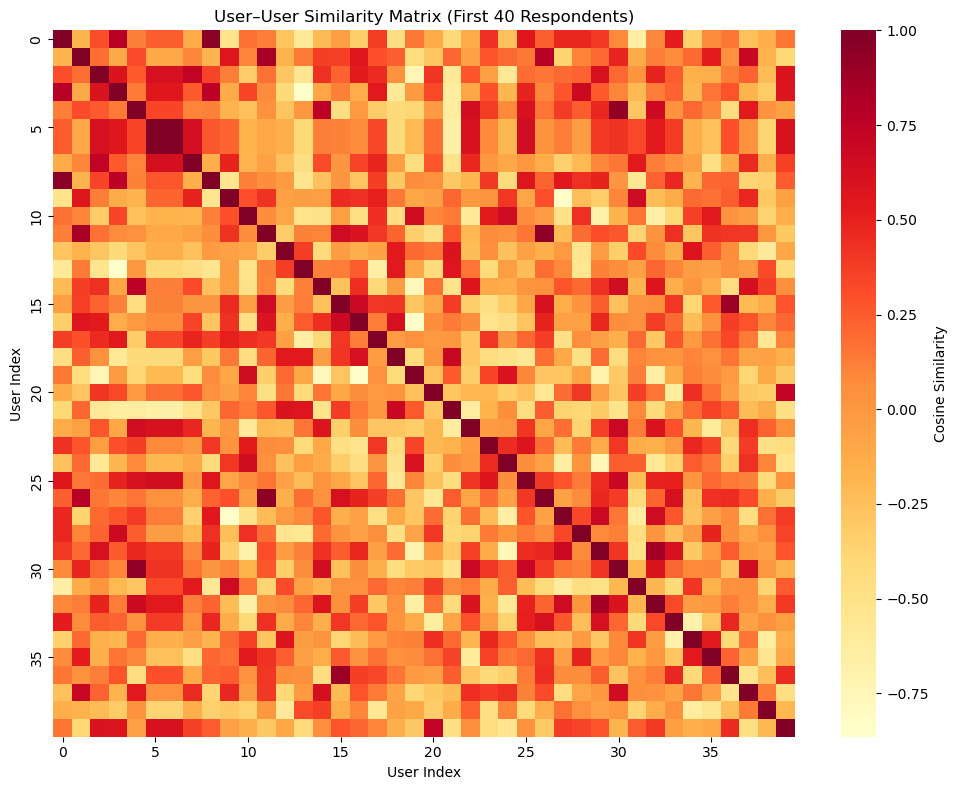

In [99]:
# Similarity heatmap (first 40 users)
plt.figure(figsize=(10, 8))
sns.heatmap(user_sim_df8.iloc[:40, :40], cmap='YlOrRd',
            xticklabels=5, yticklabels=5,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title('User–User Similarity Matrix (First 40 Respondents)')
plt.xlabel('User Index'); plt.ylabel('User Index')
plt.tight_layout(); plt.savefig('lab8_similarity_heatmap.png', dpi=120);
plt.show()